In [1]:
import pickle
from pathlib import Path
import pandas as pd
import numpy as np
import torch.nn as nn

from neuralhydrology.utils.config import Config

import matplotlib.pyplot as plt
import torch
from neuralhydrology.evaluation import metrics
from neuralhydrology.nh_run import start_run, eval_run

from neuralhydrology.evaluation.metrics import nse
import xarray as xr

# dCFE (Need Fixing)

## Ratio of NSEs
Experiements are ran over the `basin_noSnow.txt` basins at daily increments under the dynamic parameters, oracle average parameters, and operational average parameters setting. The results are under the folders:

* `EXP1_CAMELS_noSnow_HPC_Dynamic_1512_142350`
* `EXP1_CAMELS_noSnow_HPC_OracleAvg_1612_172828`
* `EXP1_CAMELS_noSnow_HPC_OperationalAvg_1612_133015`

They are already evaluated on HPC. There are some issues with how NH evaluates NSE from `predict_last_n: 365` setting and we will demonstrate this and fix this issue by sticking four sequences of length 365 predicted flows together. 
### Load Results & Wrong NSE

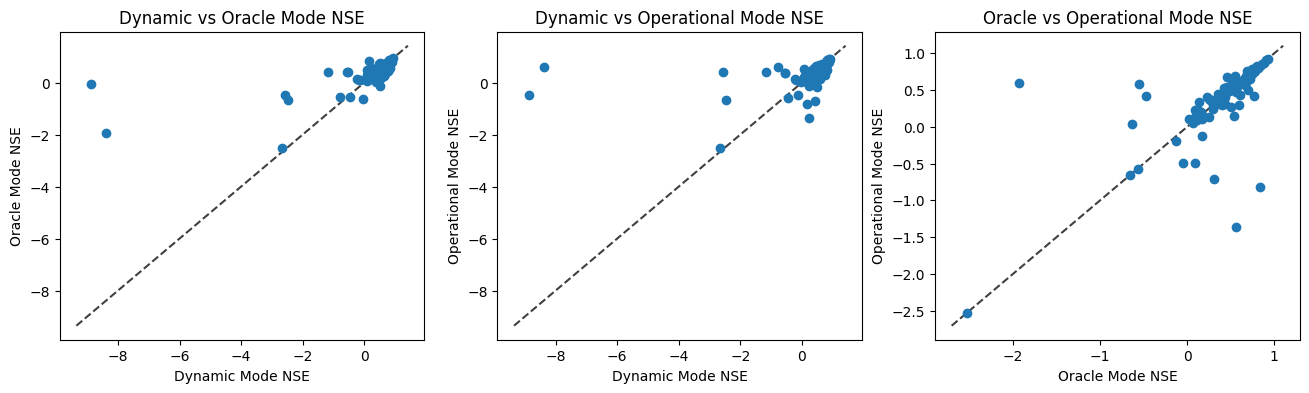

In [30]:
dynamic_path = Path("runs/EXP1_CAMELS_noSnow_HPC_Dynamic_1512_142350")
oracle_path = Path("runs/EXP1_CAMELS_noSnow_HPC_OracleAvg_1612_172828")
operational_path = Path("runs/EXP1_CAMELS_noSnow_HPC_OperationalAvg_1612_133015")

dynamic_NSE = pd.read_csv(dynamic_path / "test" / "model_epoch030" / "test_metrics.csv", index_col=0)
oracle_NSE = pd.read_csv(oracle_path / "test" / "model_epoch030" / "test_metrics.csv", index_col=0)
operational_NSE = pd.read_csv(operational_path / "test" / "model_epoch030" / "test_metrics.csv", index_col=0)

fig, ax = plt.subplots(1, 3, figsize=(16,4))
ax[0].plot(dynamic_NSE['NSE'], oracle_NSE['NSE'], 'o')
ax[0].set_title("Dynamic vs Oracle Mode NSE")
ax[0].set_xlabel("Dynamic Mode NSE")
ax[0].set_ylabel("Oracle Mode NSE")
lims0 = [np.min([ax[0].get_xlim(), ax[0].get_ylim()]), np.max([ax[0].get_xlim(), ax[0].get_ylim()])]
ax[0].plot(lims0, lims0, 'k--', alpha=0.75, zorder=0)

ax[1].plot(dynamic_NSE['NSE'], operational_NSE['NSE'], 'o')
ax[1].set_title("Dynamic vs Operational Mode NSE")
ax[1].set_xlabel("Dynamic Mode NSE")
ax[1].set_ylabel("Operational Mode NSE")
lims1 = [np.min([ax[1].get_xlim(), ax[1].get_ylim()]), np.max([ax[1].get_xlim(), ax[1].get_ylim()])]
ax[1].plot(lims1, lims1, 'k--', alpha=0.75, zorder=0)

ax[2].plot(oracle_NSE['NSE'], operational_NSE['NSE'], 'o')
ax[2].set_title("Oracle vs Operational Mode NSE")
ax[2].set_xlabel("Oracle Mode NSE")
ax[2].set_ylabel("Operational Mode NSE")
lims2 = [np.min([ax[2].get_xlim(), ax[2].get_ylim()]), np.max([ax[2].get_xlim(), ax[2].get_ylim()])]
ax[2].plot(lims2, lims2, 'k--', alpha=0.75, zorder=0)

In [32]:
with open(dynamic_path / "test" / "model_epoch030" / "test_results.p", "rb") as fp:
    dynamic_results = pickle.load(fp)
with open(oracle_path / "test" / "model_epoch030" / "test_results.p", "rb") as fp:
    oracle_results = pickle.load(fp)
with open(operational_path / "test" / "model_epoch030" / "test_results.p", "rb") as fp:
    operational_results = pickle.load(fp)

Text(0.5, 1.0, 'Dynamic, 30 epoch, Basin 08070000 - NSE 0.616')

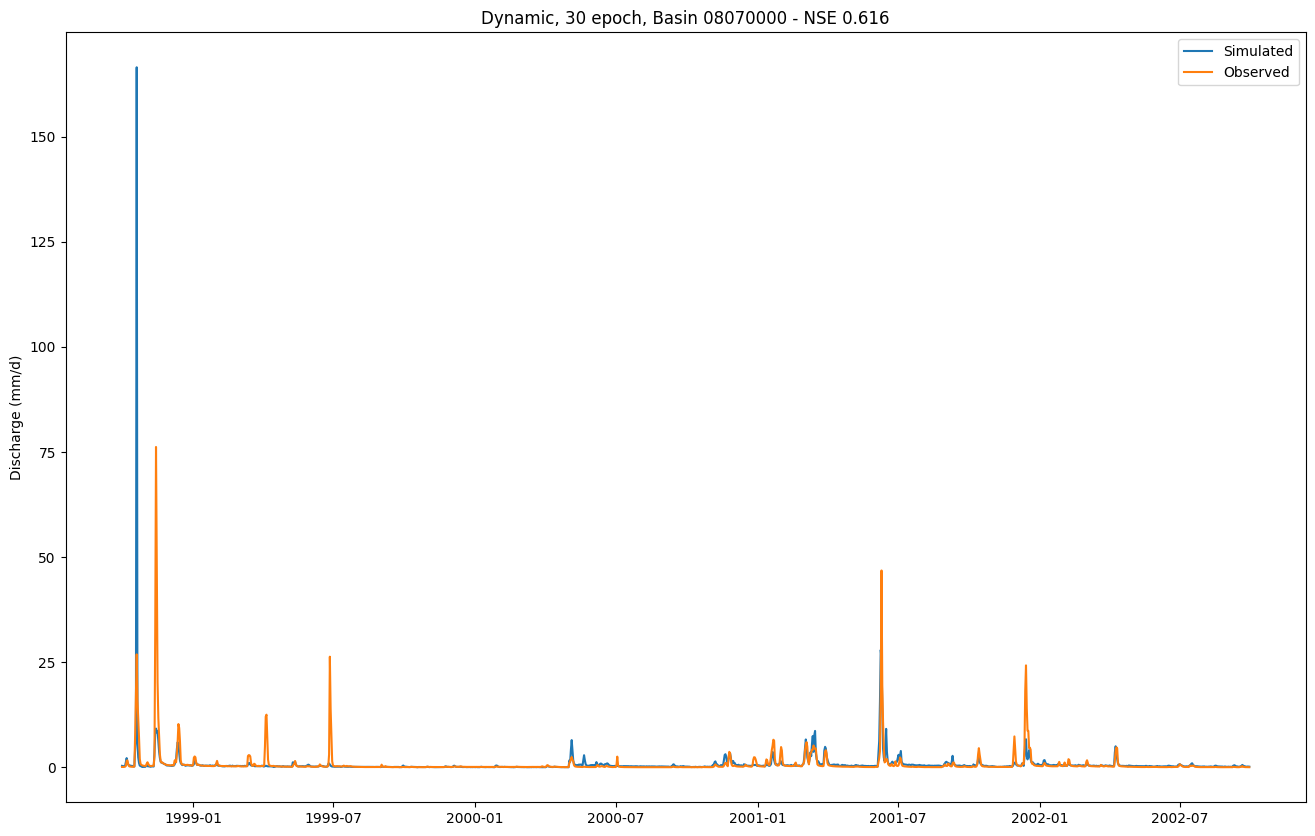

In [4]:
# Stitch them together
basin = '08070000' #'08202700' #'02231000' #'08202700'

dynamic_agg_sim = np.hstack([dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]])
dynamic_agg_obs = np.hstack([dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][0],
            dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365],
            dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*2],
            dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*3]])
dynamic_dates = pd.date_range(start='1998-10-01', periods=len(dynamic_agg_obs), freq='D')
fig, ax = plt.subplots(figsize=(16,10))
ax.plot(dynamic_dates, dynamic_agg_sim, label='Simulated')
ax.plot(dynamic_dates, dynamic_agg_obs, label='Observed')
ax.legend()
ax.set_ylabel("Discharge (mm/d)")
ax.set_title(f"Dynamic, 30 epoch, Basin {basin} - NSE {dynamic_results[basin]['1D']['NSE']:.3f}")

In [5]:
nse(xr.DataArray(dynamic_agg_obs), xr.DataArray(dynamic_agg_sim))

-0.7184476852416992

The NSE is not close: -8.379 vs -6.670

Text(0.5, 1.0, 'Oracle, 30 epoch, Basin 08070000 - NSE 0.398')

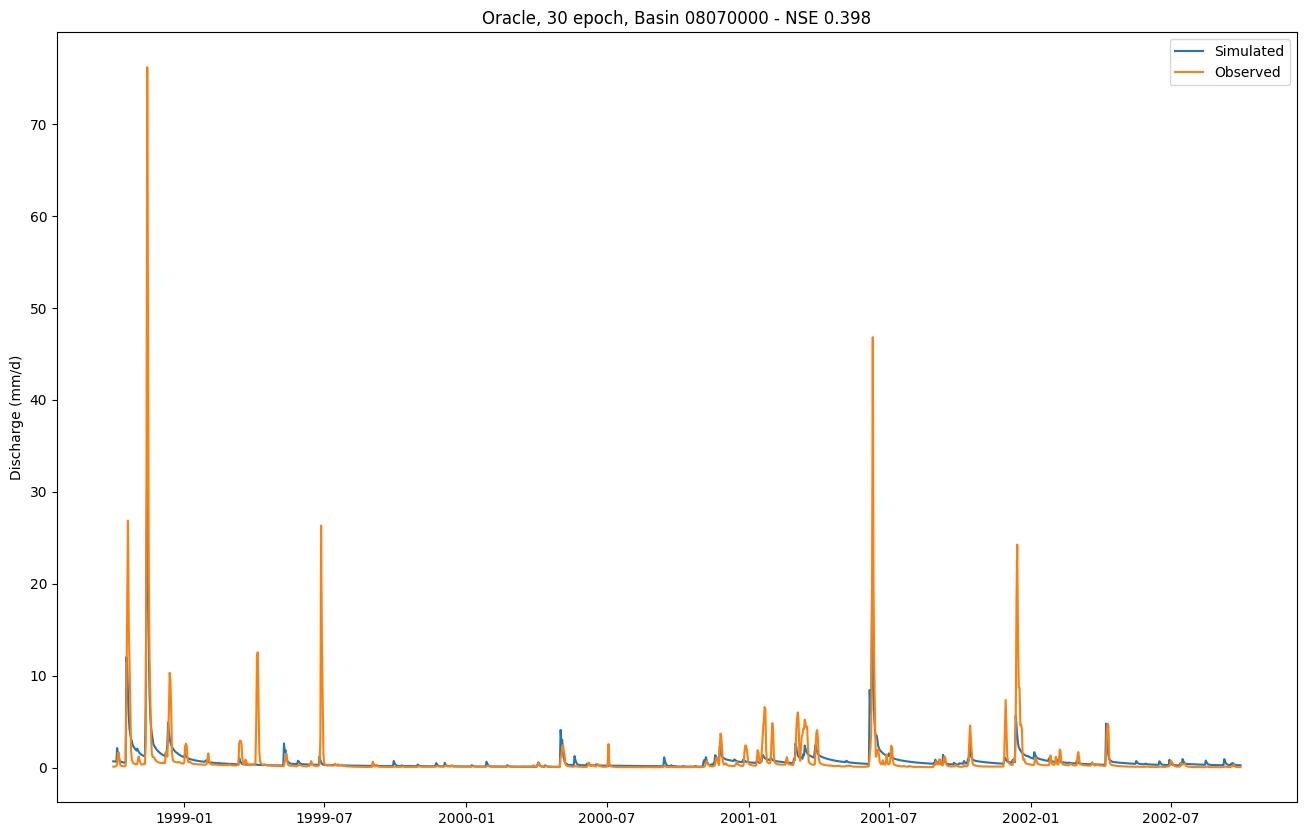

In [6]:
basin = '08070000' #'02231000'

oracle_agg_sim = xr.DataArray(
    np.hstack(
        [oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
         oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
         oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
         oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]]
        )
)
oracle_agg_obs = xr.DataArray(
    np.hstack(
        [oracle_results[basin]['1D']['xr']['QObs(mm/d)_obs'][0],
         oracle_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365],
         oracle_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*2],
         oracle_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*3]]
        )
)
oracle_dates = pd.date_range(start='1998-10-01', periods=len(oracle_agg_obs), freq='D')
fig, ax = plt.subplots(figsize=(16,10))
ax.plot(oracle_dates, oracle_agg_sim, label='Simulated')
ax.plot(oracle_dates, oracle_agg_obs, label='Observed')
ax.legend()
ax.set_ylabel("Discharge (mm/d)")
ax.set_title(f"Oracle, 30 epoch, Basin {basin} - NSE {oracle_results[basin]['1D']['NSE']:.3f}")

In [7]:
nse(oracle_agg_obs, oracle_agg_sim)

0.5639779269695282

The NSE is not close here either: -0.639 vs 0.436

## Calculate Correct NSE
We will calculate the correct NSEs for the above methods for each basin. 

In [33]:
basin_keys = list(dynamic_results.keys())

# Create dictionary to store results
nse_results = {'basin': [], 'dynamic_nse': [], 'oracle_nse': [], 'operational_nse': []}

# Dynamic Mode
for basin in basin_keys:
    dynamic_agg_sim = np.hstack([dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
             dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
             dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
             dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]])
    dynamic_agg_obs = np.hstack([dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][0],
                dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365],
                dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*2],
                dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*3]])
    dynamic_nse = nse(xr.DataArray(dynamic_agg_obs), xr.DataArray(dynamic_agg_sim))
    
    # Oracle Mode
    oracle_agg_sim = np.hstack([oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
             oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
             oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
             oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]])
    oracle_agg_obs = np.hstack([oracle_results[basin]['1D']['xr']['QObs(mm/d)_obs'][0],
                oracle_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365],
                oracle_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*2],
                oracle_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*3]])
    oracle_nse = nse(xr.DataArray(oracle_agg_obs), xr.DataArray(oracle_agg_sim))
    
    # Operational Mode
    operational_agg_sim = np.hstack([operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
             operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
             operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
             operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]])
    operational_agg_obs = np.hstack([operational_results[basin]['1D']['xr']['QObs(mm/d)_obs'][0],
                operational_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365],
                operational_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*2],
                operational_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*3]])
    operational_nse = nse(xr.DataArray(operational_agg_obs), xr.DataArray(operational_agg_sim))
    
    # Append to results dictionary
    nse_results['basin'].append(basin)
    nse_results['dynamic_nse'].append(float(dynamic_nse))
    nse_results['oracle_nse'].append(float(oracle_nse))
    nse_results['operational_nse'].append(float(operational_nse))

# Convert to DataFrame with basin as index
corrected_nse_df = pd.DataFrame(nse_results).set_index('basin')
corrected_nse_df

,dynamic_nse,oracle_nse,operational_nse
basin,,,
02092500,0.327146,0.201347,0.279044
02102908,0.133567,0.251740,0.177657
02108000,0.277122,0.204706,0.328980
02193340,0.416943,0.377654,0.345422
02196000,0.544982,0.413077,0.464156
...,...,...,...
14305500,0.812326,0.756514,0.755039
14306340,0.808776,0.801302,0.796532
14306500,0.897162,0.894188,0.892076


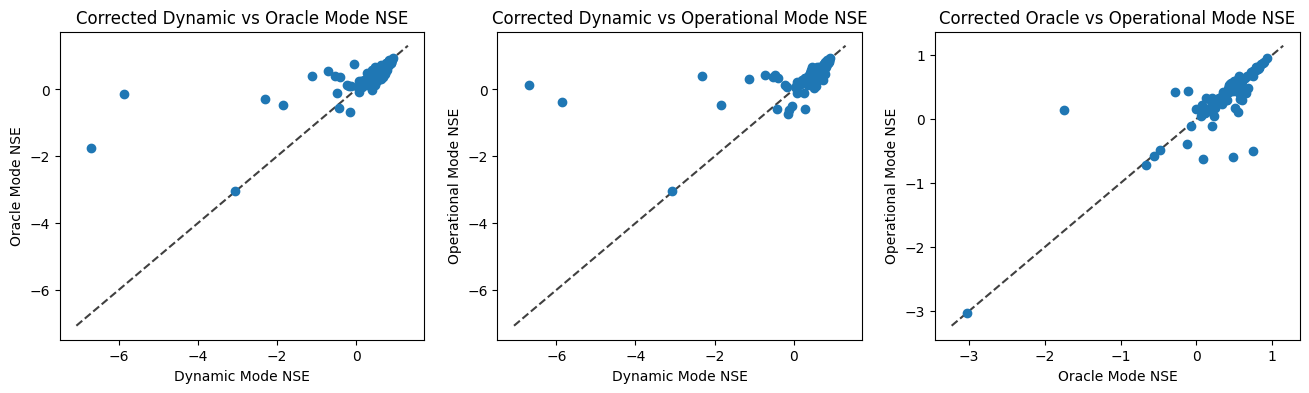

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(16,4))
ax[0].plot(corrected_nse_df['dynamic_nse'], corrected_nse_df['oracle_nse'], 'o')
ax[0].set_title("Corrected Dynamic vs Oracle Mode NSE")
ax[0].set_xlabel("Dynamic Mode NSE")
ax[0].set_ylabel("Oracle Mode NSE")
lims0 = [np.min([ax[0].get_xlim(), ax[0].get_ylim()]), np.max([ax[0].get_xlim(), ax[0].get_ylim()])]
ax[0].plot(lims0, lims0, 'k--', alpha=0.75, zorder=0)

ax[1].plot(corrected_nse_df['dynamic_nse'], corrected_nse_df['operational_nse'], 'o')
ax[1].set_title("Corrected Dynamic vs Operational Mode NSE")
ax[1].set_xlabel("Dynamic Mode NSE")
ax[1].set_ylabel("Operational Mode NSE")
lims1 = [np.min([ax[1].get_xlim(), ax[1].get_ylim()]), np.max([ax[1].get_xlim(), ax[1].get_ylim()])]
ax[1].plot(lims1, lims1, 'k--', alpha=0.75, zorder=0)

ax[2].plot(corrected_nse_df['oracle_nse'], corrected_nse_df['operational_nse'], 'o')
ax[2].set_title("Corrected Oracle vs Operational Mode NSE")
ax[2].set_xlabel("Oracle Mode NSE")
ax[2].set_ylabel("Operational Mode NSE")
lims2 = [np.min([ax[2].get_xlim(), ax[2].get_ylim()]), np.max([ax[2].get_xlim(), ax[2].get_ylim()])]
ax[2].plot(lims2, lims2, 'k--', alpha=0.75, zorder=0)

## Examining Model Performance under Different Modes

In [10]:
# Examine basins with negative dynamic NSE
negative_dynamic = corrected_nse_df[corrected_nse_df['dynamic_nse'] < 0]
print(f"Number of basins with negative dynamic NSE: {len(negative_dynamic)}")
negative_oracle = corrected_nse_df[corrected_nse_df['oracle_nse'] < 0]
print(f"Number of basins with negative oracle NSE: {len(negative_oracle)}")
negative_operational = corrected_nse_df[corrected_nse_df['operational_nse'] < 0]
print(f"Number of basins with negative operational NSE: {len(negative_operational)}")
negative_dynamic

Number of basins with negative dynamic NSE: 16
Number of basins with negative oracle NSE: 10
Number of basins with negative operational NSE: 10


,dynamic_nse,oracle_nse,operational_nse
basin,,,
02202600,-0.155953,-0.666403,-0.724359
08070000,-0.718448,0.563978,0.439348
08086212,-1.124421,0.403104,0.303246
08103900,-2.310379,-0.288088,0.417139
08150800,-0.408493,0.380186,0.336059
08158700,-0.477303,-0.114913,0.444111
08176900,-0.045776,0.748950,-0.492073
08196000,-0.177278,0.095586,0.088009
08202700,-6.689700,-1.748287,0.147186


Interestingly, there are a few observations where the NSE is negative for dynamic mode but better for cle or operational mode. And one basin that performs roughly the same across all modes. There are more negative NSEs in dynamic mode. 

In [11]:
corrected_nse_df['dynamic_nse']['08070000']

-0.7184476852416992

In [ ]:
negative_oracle # 8 basins overlap with negative dynamic NSE

,dynamic_nse,oracle_nse,operational_nse
basin,,,
02202600,-0.155953,-0.666403,-0.724359
07375000,0.390056,-0.008443,0.156161
08082700,0.069758,-0.066150,-0.108458
08103900,-2.310379,-0.288088,0.417139
08158700,-0.477303,-0.114913,0.444111
08202700,-6.689700,-1.748287,0.147186
09447800,-5.864542,-0.122838,-0.382981
09510200,-0.432308,-0.560175,-0.577509
09512280,-1.839701,-0.478152,-0.478142


In [ ]:
negative_operational # 7 overlap with negative dynamic NSE

,dynamic_nse,oracle_nse,operational_nse
basin,,,
02202600,-0.155953,-0.666403,-0.724359
02246000,0.265013,0.207831,-0.100637
08082700,0.069758,-0.066150,-0.108458
08164600,0.271835,0.479358,-0.597269
08176900,-0.045776,0.748950,-0.492073
09447800,-5.864542,-0.122838,-0.382981
09508300,-0.125937,0.093260,-0.627133
09510200,-0.432308,-0.560175,-0.577509
09512280,-1.839701,-0.478152,-0.478142


### Example of Dynamic Mode worse than Averaging

Text(0, 0.5, 'Discharge (mm/d)')

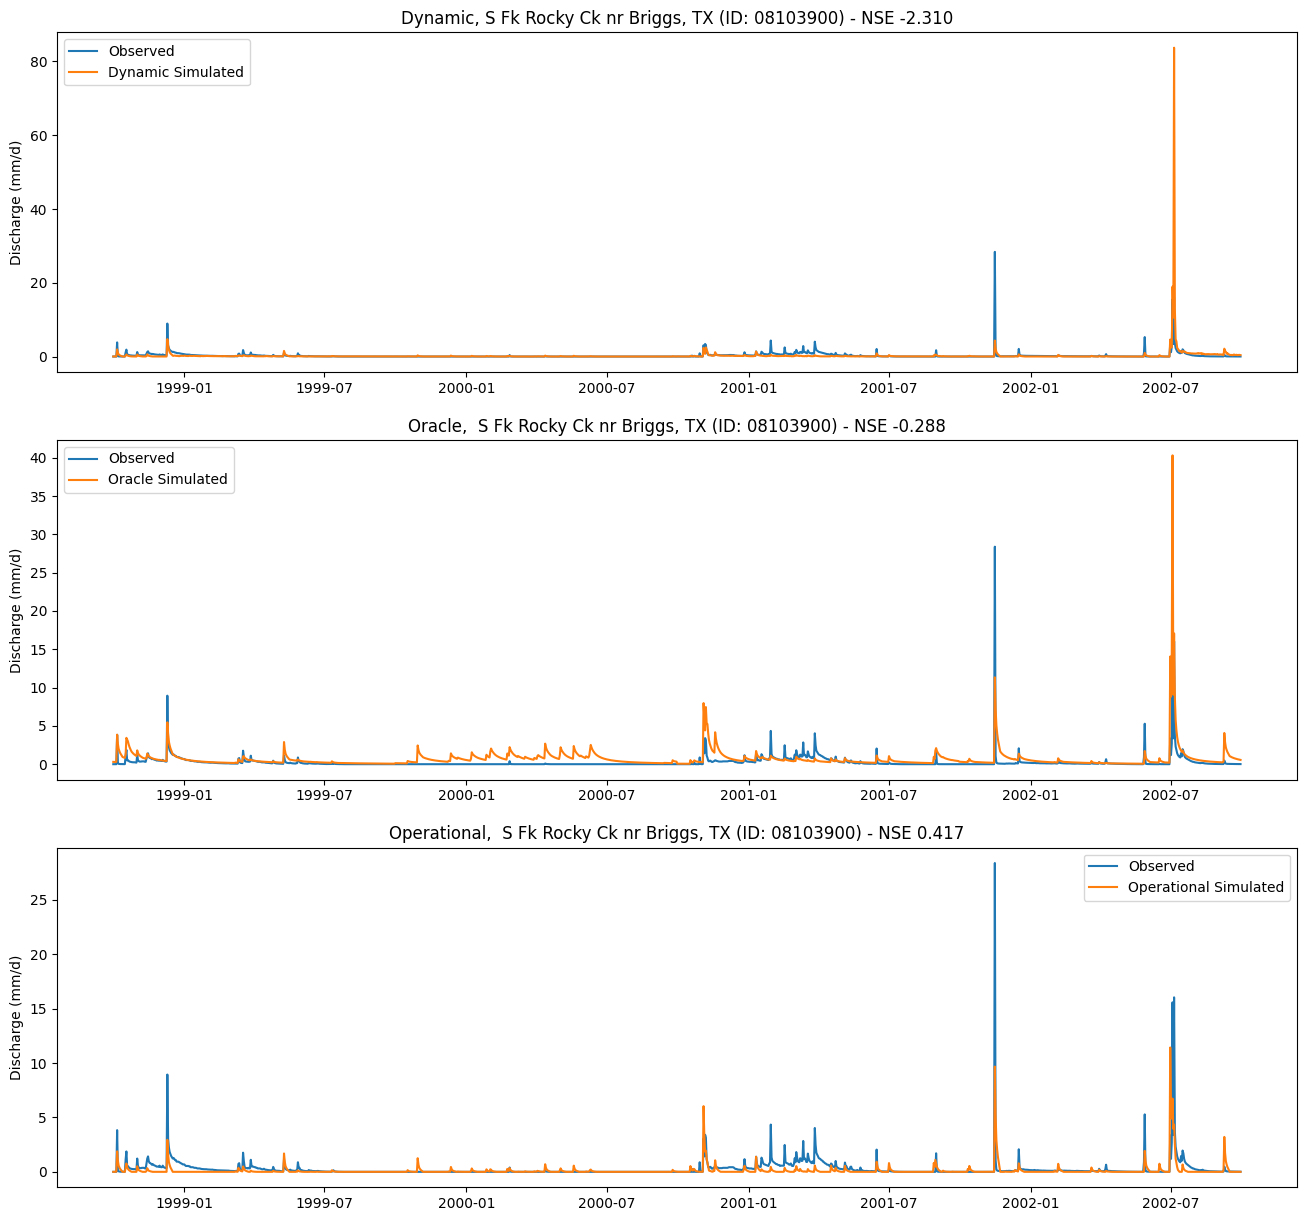

In [ ]:
basin = '08103900' # S Fk Rocky Ck nr Briggs, TX 

# dynamic
dynamic_agg_sim = xr.DataArray(
    np.hstack(
        [dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]]
        )
)
dynamic_agg_obs = xr.DataArray(
    np.hstack(
        [dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][0],
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365],
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*2],
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*3]]
        )
)
# oracle
oracle_agg_sim = xr.DataArray(
    np.hstack(
        [oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
         oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
         oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
         oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]]
        )
)
# operational
operational_agg_sim = xr.DataArray(
    np.hstack(
        [operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
         operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
         operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
         operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]]
        )
)
dates = pd.date_range(start='1998-10-01', periods=len(oracle_agg_obs), freq='D')

fig, ax = plt.subplots(3, 1, figsize=(16,15))
ax[0].plot(dates, dynamic_agg_obs, label='Observed')
ax[0].plot(dates, dynamic_agg_sim, label='Dynamic Simulated')
ax[0].set_title(f"Dynamic, S Fk Rocky Ck nr Briggs, TX (ID: {basin}) - NSE {corrected_nse_df['dynamic_nse'][basin]:.3f}")
ax[0].legend()
ax[0].set_ylabel("Discharge (mm/d)")

ax[1].plot(dates, dynamic_agg_obs, label='Observed')
ax[1].plot(dates, oracle_agg_sim, label='Oracle Simulated')
ax[1].set_title(f"Oracle,  S Fk Rocky Ck nr Briggs, TX (ID: {basin}) - NSE {corrected_nse_df['oracle_nse'][basin]:.3f}")
ax[1].legend()
ax[1].set_ylabel("Discharge (mm/d)")

ax[2].plot(dates, dynamic_agg_obs, label='Observed')
ax[2].plot(dates, operational_agg_sim, label='Operational Simulated')
ax[2].set_title(f"Operational,  S Fk Rocky Ck nr Briggs, TX (ID: {basin}) - NSE {corrected_nse_df['operational_nse'][basin]:.3f}")
ax[2].legend()
ax[2].set_ylabel("Discharge (mm/d)")



### Example where all modes perform similarly

Text(0, 0.5, 'Discharge (mm/d)')

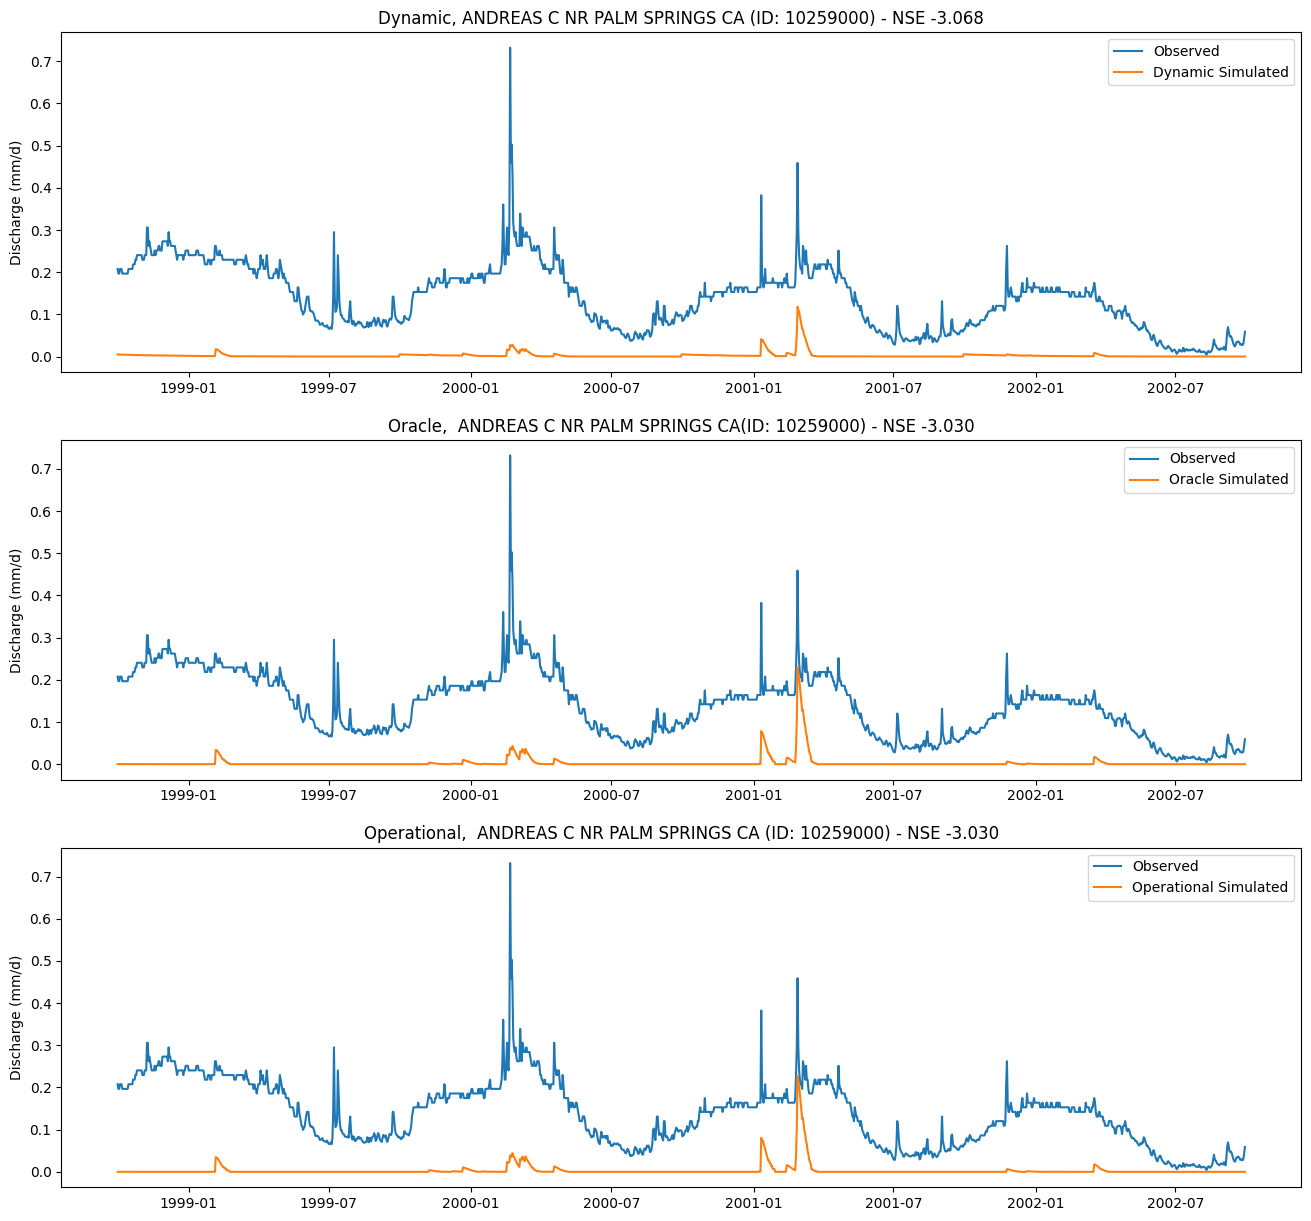

In [62]:
basin = '10259000' # ANDREAS C NR PALM SPRINGS CA

# dynamic
dynamic_agg_sim = xr.DataArray(
    np.hstack(
        [dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]]
        )
)
dynamic_agg_obs = xr.DataArray(
    np.hstack(
        [dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][0],
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365],
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*2],
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*3]]
        )
)
# oracle
oracle_agg_sim = xr.DataArray(
    np.hstack(
        [oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
         oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
         oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
         oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]]
        )
)
# operational
operational_agg_sim = xr.DataArray(
    np.hstack(
        [operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
         operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
         operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
         operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]]
        )
)
dates = pd.date_range(start='1998-10-01', periods=len(oracle_agg_obs), freq='D')

fig, ax = plt.subplots(3, 1, figsize=(16,15))
ax[0].plot(dates, dynamic_agg_obs, label='Observed')
ax[0].plot(dates, dynamic_agg_sim, label='Dynamic Simulated')
ax[0].set_title(f"Dynamic, ANDREAS C NR PALM SPRINGS CA (ID: {basin}) - NSE {corrected_nse_df['dynamic_nse'][basin]:.3f}")
ax[0].legend()
ax[0].set_ylabel("Discharge (mm/d)")

ax[1].plot(dates, dynamic_agg_obs, label='Observed')
ax[1].plot(dates, oracle_agg_sim, label='Oracle Simulated')
ax[1].set_title(f"Oracle,  ANDREAS C NR PALM SPRINGS CA(ID: {basin}) - NSE {corrected_nse_df['oracle_nse'][basin]:.3f}")
ax[1].legend()
ax[1].set_ylabel("Discharge (mm/d)")

ax[2].plot(dates, dynamic_agg_obs, label='Observed')
ax[2].plot(dates, operational_agg_sim, label='Operational Simulated')
ax[2].set_title(f"Operational,  ANDREAS C NR PALM SPRINGS CA (ID: {basin}) - NSE {corrected_nse_df['operational_nse'][basin]:.3f}")
ax[2].legend()
ax[2].set_ylabel("Discharge (mm/d)")

### Example of Dynamic Mode Better than Others

Text(0, 0.5, 'Discharge (mm/d)')

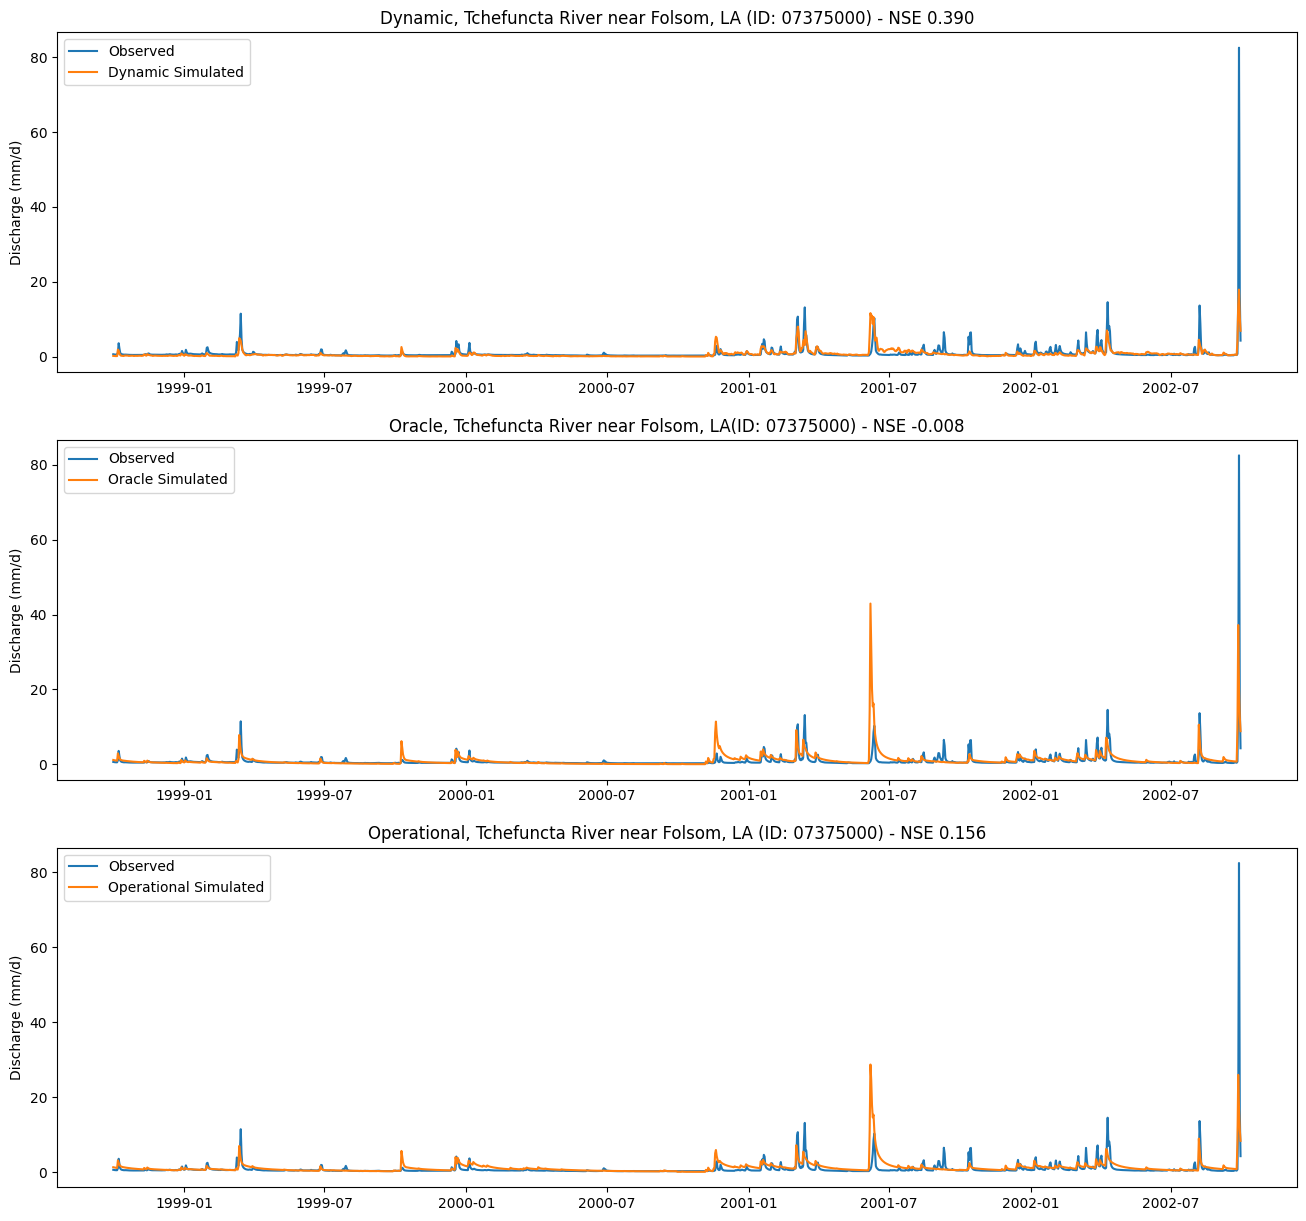

In [64]:
basin = '07375000' # Tchefuncta River near Folsom, LA

# dynamic
dynamic_agg_sim = xr.DataArray(
    np.hstack(
        [dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]]
        )
)
dynamic_agg_obs = xr.DataArray(
    np.hstack(
        [dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][0],
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365],
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*2],
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*3]]
        )
)
# oracle
oracle_agg_sim = xr.DataArray(
    np.hstack(
        [oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
         oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
         oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
         oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]]
        )
)
# operational
operational_agg_sim = xr.DataArray(
    np.hstack(
        [operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
         operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
         operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
         operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]]
        )
)
dates = pd.date_range(start='1998-10-01', periods=len(oracle_agg_obs), freq='D')

fig, ax = plt.subplots(3, 1, figsize=(16,15))
ax[0].plot(dates, dynamic_agg_obs, label='Observed')
ax[0].plot(dates, dynamic_agg_sim, label='Dynamic Simulated')
ax[0].set_title(f"Dynamic, Tchefuncta River near Folsom, LA (ID: {basin}) - NSE {corrected_nse_df['dynamic_nse'][basin]:.3f}")
ax[0].legend()
ax[0].set_ylabel("Discharge (mm/d)")

ax[1].plot(dates, dynamic_agg_obs, label='Observed')
ax[1].plot(dates, oracle_agg_sim, label='Oracle Simulated')
ax[1].set_title(f"Oracle, Tchefuncta River near Folsom, LA(ID: {basin}) - NSE {corrected_nse_df['oracle_nse'][basin]:.3f}")
ax[1].legend()
ax[1].set_ylabel("Discharge (mm/d)")

ax[2].plot(dates, dynamic_agg_obs, label='Observed')
ax[2].plot(dates, operational_agg_sim, label='Operational Simulated')
ax[2].set_title(f"Operational, Tchefuncta River near Folsom, LA (ID: {basin}) - NSE {corrected_nse_df['operational_nse'][basin]:.3f}")
ax[2].legend()
ax[2].set_ylabel("Discharge (mm/d)")

### Example of Oracle Better than Operational

Text(0, 0.5, 'Discharge (mm/d)')

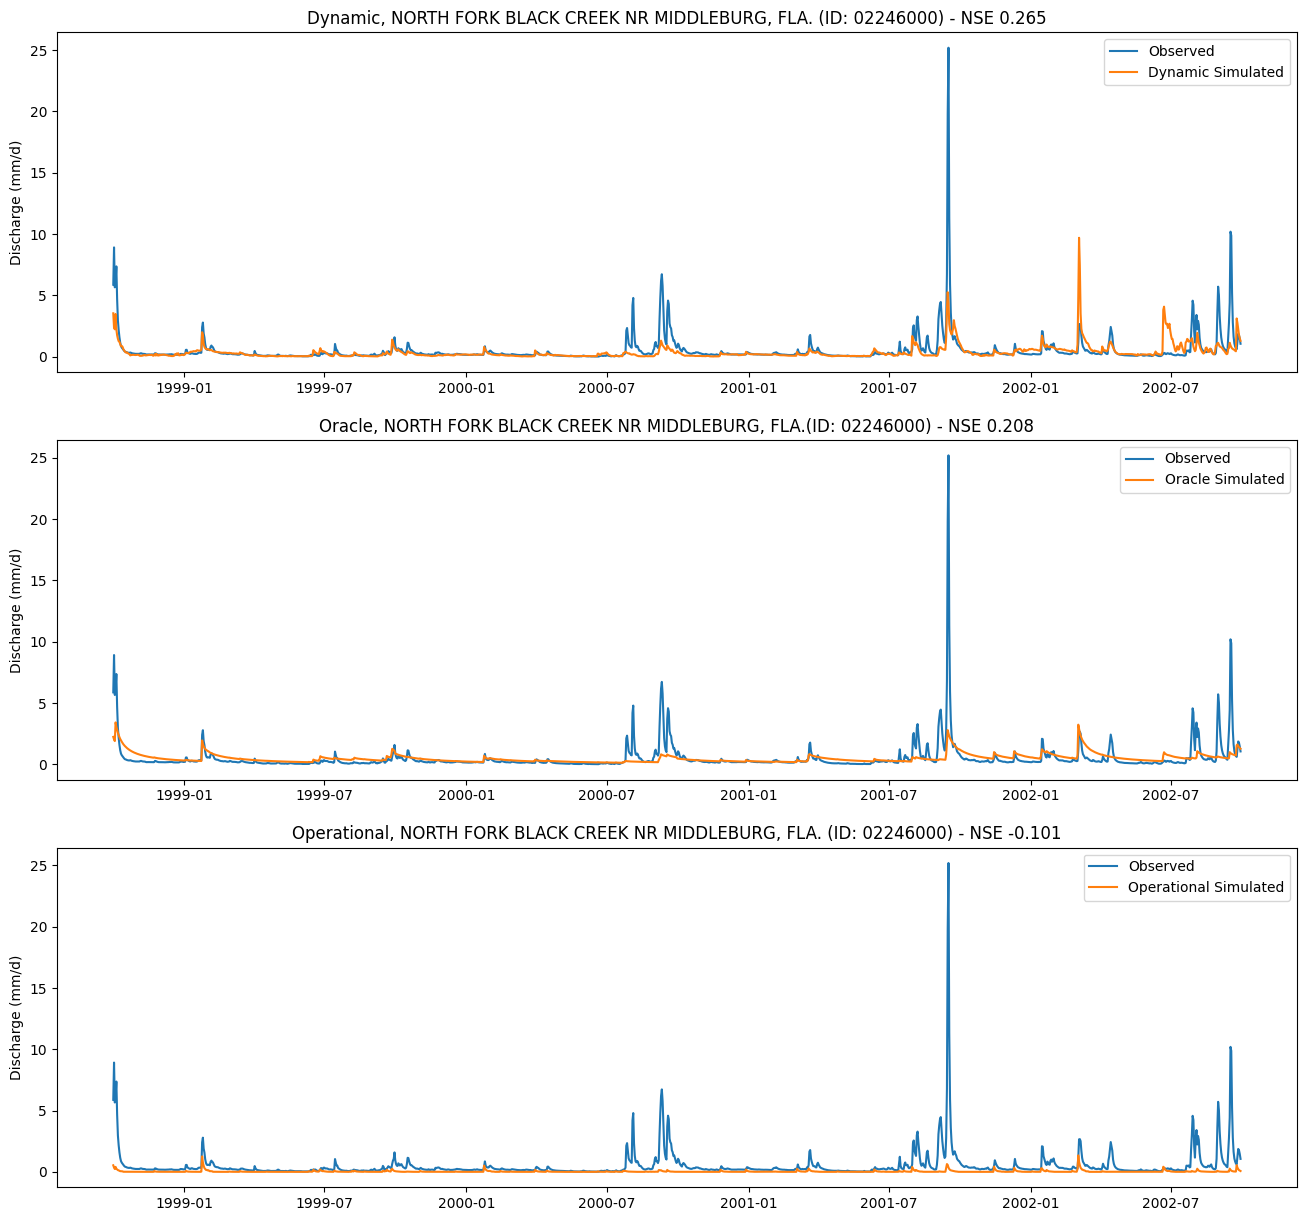

In [ ]:
basin = '02246000' # Tchefuncta River near Folsom, LA

# dynamic
dynamic_agg_sim = xr.DataArray(
    np.hstack(
        [dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]]
        )
)
dynamic_agg_obs = xr.DataArray(
    np.hstack(
        [dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][0],
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365],
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*2],
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*3]]
        )
)
# oracle
oracle_agg_sim = xr.DataArray(
    np.hstack(
        [oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
         oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
         oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
         oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]]
        )
)
# operational
operational_agg_sim = xr.DataArray(
    np.hstack(
        [operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
         operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
         operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
         operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]]
        )
)
dates = pd.date_range(start='1998-10-01', periods=len(oracle_agg_obs), freq='D')

fig, ax = plt.subplots(3, 1, figsize=(16,15))
ax[0].plot(dates, dynamic_agg_obs, label='Observed')
ax[0].plot(dates, dynamic_agg_sim, label='Dynamic Simulated')
ax[0].set_title(f"Dynamic, NORTH FORK BLACK CREEK NR MIDDLEBURG, FLA. (ID: {basin}) - NSE {corrected_nse_df['dynamic_nse'][basin]:.3f}")
ax[0].legend()
ax[0].set_ylabel("Discharge (mm/d)")

ax[1].plot(dates, dynamic_agg_obs, label='Observed')
ax[1].plot(dates, oracle_agg_sim, label='Oracle Simulated')
ax[1].set_title(f"Oracle, NORTH FORK BLACK CREEK NR MIDDLEBURG, FLA.(ID: {basin}) - NSE {corrected_nse_df['oracle_nse'][basin]:.3f}")
ax[1].legend()
ax[1].set_ylabel("Discharge (mm/d)")

ax[2].plot(dates, dynamic_agg_obs, label='Observed')
ax[2].plot(dates, operational_agg_sim, label='Operational Simulated')
ax[2].set_title(f"Operational, NORTH FORK BLACK CREEK NR MIDDLEBURG, FLA. (ID: {basin}) - NSE {corrected_nse_df['operational_nse'][basin]:.3f}")
ax[2].legend()
ax[2].set_ylabel("Discharge (mm/d)")

## Other Metrics & Comparison

In [12]:
from neuralhydrology.evaluation.metrics import rmse, kge

In [34]:
basin_keys = list(dynamic_results.keys())

# Create dictionary to store results
rmse_results = {'basin': [], 'dynamic_rmse': [], 'oracle_rmse': [], 'operational_rmse': []}

# Dynamic Mode
for basin in basin_keys:
    dynamic_agg_sim = np.hstack([dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
             dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
             dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
             dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]])
    dynamic_agg_obs = np.hstack([dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][0],
                dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365],
                dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*2],
                dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*3]])
    dynamic_rmse = rmse(xr.DataArray(dynamic_agg_obs), xr.DataArray(dynamic_agg_sim))
    
    # Oracle Mode
    oracle_agg_sim = np.hstack([oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
             oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
             oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
             oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]])
    oracle_agg_obs = np.hstack([oracle_results[basin]['1D']['xr']['QObs(mm/d)_obs'][0],
                oracle_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365],
                oracle_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*2],
                oracle_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*3]])
    oracle_rmse = rmse(xr.DataArray(oracle_agg_obs), xr.DataArray(oracle_agg_sim))
    
    # Operational Mode
    operational_agg_sim = np.hstack([operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
             operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
             operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
             operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]])
    operational_agg_obs = np.hstack([operational_results[basin]['1D']['xr']['QObs(mm/d)_obs'][0],
                operational_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365],
                operational_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*2],
                operational_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*3]])
    operational_rmse = rmse(xr.DataArray(operational_agg_obs), xr.DataArray(operational_agg_sim))
    
    # Append to results dictionary
    rmse_results['basin'].append(basin)
    rmse_results['dynamic_rmse'].append(float(dynamic_rmse))
    rmse_results['oracle_rmse'].append(float(oracle_rmse))
    rmse_results['operational_rmse'].append(float(operational_rmse))

# Convert to DataFrame with basin as index
rmse_df = pd.DataFrame(rmse_results).set_index('basin')
rmse_df

,dynamic_rmse,oracle_rmse,operational_rmse
basin,,,
02092500,2.579421,2.810222,2.670029
02102908,0.770063,0.715624,0.750214
02108000,2.354926,2.470067,2.268886
02193340,1.128721,1.166130,1.195947
02196000,0.494810,0.561972,0.536961
...,...,...,...
14305500,5.302262,6.039435,6.057701
14306340,3.624660,3.694817,3.738896
14306500,2.097770,2.127893,2.149019


In [35]:
# Create dictionary to store results
kge_results = {'basin': [], 'dynamic_kge': [], 'oracle_kge': [], 'operational_kge': []}

# Dynamic Mode
for basin in basin_keys:
    dynamic_agg_sim = np.hstack([dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
             dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
             dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
             dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]])
    dynamic_agg_obs = np.hstack([dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][0],
                dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365],
                dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*2],
                dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*3]])
    dynamic_kge = kge(xr.DataArray(dynamic_agg_obs), xr.DataArray(dynamic_agg_sim))
    
    # Oracle Mode
    oracle_agg_sim = np.hstack([oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
             oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
             oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
             oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]])
    oracle_agg_obs = np.hstack([oracle_results[basin]['1D']['xr']['QObs(mm/d)_obs'][0],
                oracle_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365],
                oracle_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*2],
                oracle_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*3]])
    oracle_kge = kge(xr.DataArray(oracle_agg_obs), xr.DataArray(oracle_agg_sim))
    
    # Operational Mode
    operational_agg_sim = np.hstack([operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
             operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
             operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
             operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]])
    operational_agg_obs = np.hstack([operational_results[basin]['1D']['xr']['QObs(mm/d)_obs'][0],
                operational_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365],
                operational_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*2],
                operational_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*3]])
    operational_kge = kge(xr.DataArray(operational_agg_obs), xr.DataArray(operational_agg_sim))
    
    # Append to results dictionary
    kge_results['basin'].append(basin)
    kge_results['dynamic_kge'].append(float(dynamic_kge))
    kge_results['oracle_kge'].append(float(oracle_kge))
    kge_results['operational_kge'].append(float(operational_kge))

# Convert to DataFrame with basin as index
kge_df = pd.DataFrame(kge_results).set_index('basin')
kge_df

,dynamic_kge,oracle_kge,operational_kge
basin,,,
02092500,0.287846,0.027944,0.193093
02102908,0.560819,0.409208,0.598203
02108000,0.169755,0.021438,0.182645
02193340,0.260391,0.409539,0.312249
02196000,0.392883,0.190524,0.513181
...,...,...,...
14305500,0.867154,0.790861,0.775077
14306340,0.836103,0.783548,0.767716
14306500,0.916702,0.930276,0.945039


## Compare all 3 metrics

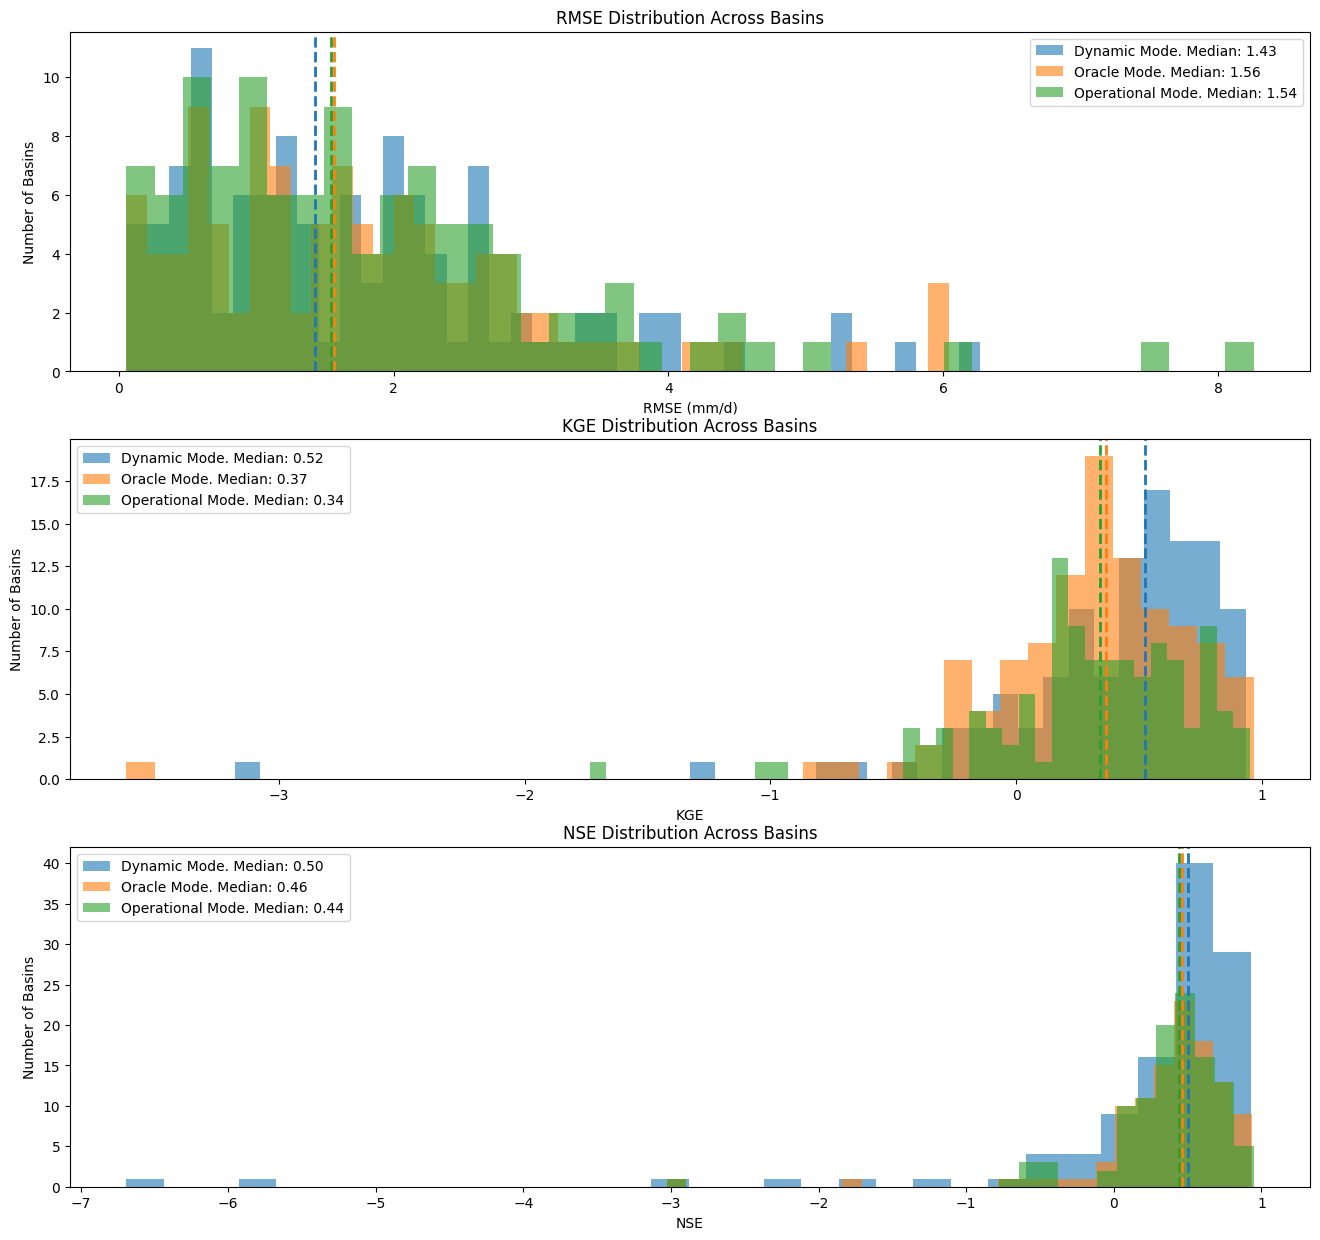

In [24]:
num_bins = 40
a = 0.6

fig, ax = plt.subplots(3, 1, figsize=(16,15))
ax[0].hist(rmse_df['dynamic_rmse'], bins=num_bins, alpha=a, label='Dynamic Mode. Median: {:.2f}'.format(rmse_df['dynamic_rmse'].median()))
ax[0].axvline(rmse_df['dynamic_rmse'].median(), color='tab:blue', linestyle='dashed', linewidth=2)
ax[0].hist(rmse_df['oracle_rmse'], bins=num_bins, alpha=a, label='Oracle Mode. Median: {:.2f}'.format(rmse_df['oracle_rmse'].median()))
ax[0].axvline(rmse_df['oracle_rmse'].median(), color='tab:orange', linestyle='dashed', linewidth=2)
ax[0].hist(rmse_df['operational_rmse'], bins=num_bins, alpha=a, label='Operational Mode. Median: {:.2f}'.format(rmse_df['operational_rmse'].median()))
ax[0].axvline(rmse_df['operational_rmse'].median(), color='tab:green', linestyle='dashed', linewidth=2)
ax[0].set_title("RMSE Distribution Across Basins")
ax[0].set_xlabel("RMSE (mm/d)")
ax[0].set_ylabel("Number of Basins")
ax[0].legend() 

ax[1].hist(kge_df['dynamic_kge'], bins=num_bins, alpha=a, label='Dynamic Mode. Median: {:.2f}'.format(kge_df['dynamic_kge'].median()))
ax[1].axvline(kge_df['dynamic_kge'].median(), color='tab:blue', linestyle='dashed', linewidth=2)
ax[1].hist(kge_df['oracle_kge'], bins=num_bins, alpha=a, label='Oracle Mode. Median: {:.2f}'.format(kge_df['oracle_kge'].median()))
ax[1].axvline(kge_df['oracle_kge'].median(), color='tab:orange', linestyle='dashed', linewidth=2)
ax[1].hist(kge_df['operational_kge'], bins=num_bins, alpha=a, label='Operational Mode. Median: {:.2f}'.format(kge_df['operational_kge'].median()))
ax[1].axvline(kge_df['operational_kge'].median(), color='tab:green', linestyle='dashed', linewidth=2)
ax[1].set_title("KGE Distribution Across Basins")
ax[1].set_xlabel("KGE")
ax[1].set_ylabel("Number of Basins")
ax[1].legend() 

ax[2].hist(corrected_nse_df['dynamic_nse'], bins=30, alpha=a, label='Dynamic Mode. Median: {:.2f}'.format(corrected_nse_df['dynamic_nse'].median()))
ax[2].axvline(corrected_nse_df['dynamic_nse'].median(), color='tab:blue', linestyle='dashed', linewidth=2)
ax[2].hist(corrected_nse_df['oracle_nse'], bins=30, alpha=a, label='Oracle Mode. Median: {:.2f}'.format(corrected_nse_df['oracle_nse'].median()))
ax[2].axvline(corrected_nse_df['oracle_nse'].median(), color='tab:orange', linestyle='dashed', linewidth=2)
ax[2].hist(corrected_nse_df['operational_nse'], bins=30, alpha=a, label='Operational Mode. Median: {:.2f}'.format(corrected_nse_df['operational_nse'].median()))
ax[2].axvline(corrected_nse_df['operational_nse'].median(), color='tab:green', linestyle='dashed', linewidth=2)
ax[2].set_title("NSE Distribution Across Basins")
ax[2].set_xlabel("NSE")
ax[2].set_ylabel("Number of Basins")
ax[2].legend()

## Grab cocneptual prameters (Need Work)

In [ ]:
basin = '02246000' # Tchefuncta River near Folsom, LA
oracle_results[basin]

{'1D': {'xr': <xarray.Dataset> Size: 3MB
  Dimensions:         (date: 1097, time_step: 365)
  Coordinates:
    * date            (date) datetime64[ns] 9kB 1999-09-30 ... 2002-09-30
    * time_step       (time_step) int64 3kB -364 -363 -362 -361 ... -3 -2 -1 0
  Data variables:
      QObs(mm/d)_obs  (date, time_step) float32 2MB 5.873 8.916 ... 1.057 0.8222
      QObs(mm/d)_sim  (date, time_step) float32 2MB 2.242 2.041 ... 1.276 1.231,
  'NSE': 0.16945642232894897}}

# SHM (Need Fixing)
Same configuration adapted for SHM model. 
## Metrics Comparison: NSE, RMSE, KGE

In [1]:
import pickle
from pathlib import Path
import pandas as pd
import numpy as np
import torch.nn as nn

from neuralhydrology.utils.config import Config

import matplotlib.pyplot as plt
import torch
from neuralhydrology.evaluation import metrics
from neuralhydrology.nh_run import start_run, eval_run

from neuralhydrology.evaluation.metrics import nse, rmse, kge
import xarray as xr

In [36]:
shm_dynamic_path = Path("runs/EXP1_SHM_CAMELS_noSnow_Dynamic_2901_143452")
shm_oracle_path = Path("runs/EXP1_SHM_CAMELS_noSnow_OracleAvg_2901_153236")
shm_operational_path = Path("runs/EXP1_SHM_CAMELS_noSnow_OperationalAvg_2901_163450")

with open(shm_dynamic_path / "test" / "model_epoch030" / "test_results.p", "rb") as fp:
    shm_dynamic_results = pickle.load(fp)
with open(shm_oracle_path / "test" / "model_epoch030" / "test_results.p", "rb") as fp:
    shm_oracle_results = pickle.load(fp)
with open(shm_operational_path / "test" / "model_epoch030" / "test_results.p", "rb") as fp:
    shm_operational_results = pickle.load(fp)


In [37]:
basin_keys = list(shm_dynamic_results.keys())

# Create dictionary to store results
shm_metric_results = {'basin': [], 'dynamic_nse': [], 'oracle_nse': [], 'operational_nse': [],
                      'dynamic_rmse': [], 'oracle_rmse': [], 'operational_rmse': [],
                     'dynamic_kge': [], 'oracle_kge': [], 'operational_kge': []}

# Dynamic Mode
for basin in basin_keys:
    dynamic_agg_sim = np.hstack([shm_dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
             shm_dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
             shm_dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
             shm_dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]])
    dynamic_agg_obs = np.hstack([shm_dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][0],
                shm_dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365],
                shm_dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*2],
                shm_dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*3]])
    dynamic_nse = nse(xr.DataArray(dynamic_agg_obs), xr.DataArray(dynamic_agg_sim))
    dynamic_rmse = rmse(xr.DataArray(dynamic_agg_obs), xr.DataArray(dynamic_agg_sim))
    dynamic_kge = kge(xr.DataArray(dynamic_agg_obs), xr.DataArray(dynamic_agg_sim))
    
    # Oracle Mode
    oracle_agg_sim = np.hstack([shm_oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
             shm_oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
             shm_oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
             shm_oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]])
    oracle_agg_obs = np.hstack([shm_oracle_results[basin]['1D']['xr']['QObs(mm/d)_obs'][0],
                shm_oracle_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365],
                shm_oracle_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*2],
                shm_oracle_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*3]])
    oracle_nse = nse(xr.DataArray(oracle_agg_obs), xr.DataArray(oracle_agg_sim))
    oracle_rmse = rmse(xr.DataArray(oracle_agg_obs), xr.DataArray(oracle_agg_sim))
    oracle_kge = kge(xr.DataArray(oracle_agg_obs), xr.DataArray(oracle_agg_sim))
    
    # Operational Mode
    operational_agg_sim = np.hstack([shm_operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
             shm_operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
             shm_operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
             shm_operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]])
    operational_agg_obs = np.hstack([shm_operational_results[basin]['1D']['xr']['QObs(mm/d)_obs'][0],
                shm_operational_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365],
                shm_operational_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*2],
                shm_operational_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*3]])
    operational_nse = nse(xr.DataArray(operational_agg_obs), xr.DataArray(operational_agg_sim))
    operational_rmse = rmse(xr.DataArray(operational_agg_obs), xr.DataArray(operational_agg_sim))
    operational_kge = kge(xr.DataArray(operational_agg_obs), xr.DataArray(operational_agg_sim))
    
    # Append to results dictionary
    shm_metric_results['basin'].append(basin)
    shm_metric_results['dynamic_nse'].append(float(dynamic_nse))
    shm_metric_results['dynamic_rmse'].append(float(dynamic_rmse))
    shm_metric_results['dynamic_kge'].append(float(dynamic_kge))
    shm_metric_results['oracle_nse'].append(float(oracle_nse))
    shm_metric_results['oracle_rmse'].append(float(oracle_rmse))
    shm_metric_results['oracle_kge'].append(float(oracle_kge))
    shm_metric_results['operational_nse'].append(float(operational_nse))
    shm_metric_results['operational_rmse'].append(float(operational_rmse))
    shm_metric_results['operational_kge'].append(float(operational_kge))

# Convert to DataFrame with basin as index
shm_metrics = pd.DataFrame(shm_metric_results).set_index('basin')
shm_metrics

,dynamic_nse,oracle_nse,operational_nse,dynamic_rmse,oracle_rmse,operational_rmse,dynamic_kge,oracle_kge,operational_kge
basin,,,,,,,,,
02092500,0.332014,0.357529,0.264915,2.570072,2.520509,2.696065,0.227260,0.293872,0.176374
02102908,0.422426,0.203211,0.240603,0.628728,0.738466,0.720930,0.640455,0.554475,0.621468
02108000,0.370521,0.283814,0.300992,2.197533,2.344001,2.315719,0.239605,0.111817,0.144523
02193340,0.441583,0.453177,0.469404,1.104614,1.093087,1.076746,0.362482,0.315765,0.345984
02196000,0.410462,0.562826,0.525458,0.563222,0.485011,0.505314,-0.116887,0.502898,0.384749
...,...,...,...,...,...,...,...,...,...
14305500,0.769218,0.722305,0.714238,5.879767,6.449748,6.542761,0.831709,0.717035,0.743527
14306340,0.824433,0.813991,0.824452,3.473097,3.574892,3.472912,0.820995,0.769993,0.780809
14306500,0.886268,0.889642,0.887072,2.206092,2.173118,2.198277,0.881981,0.931985,0.927828


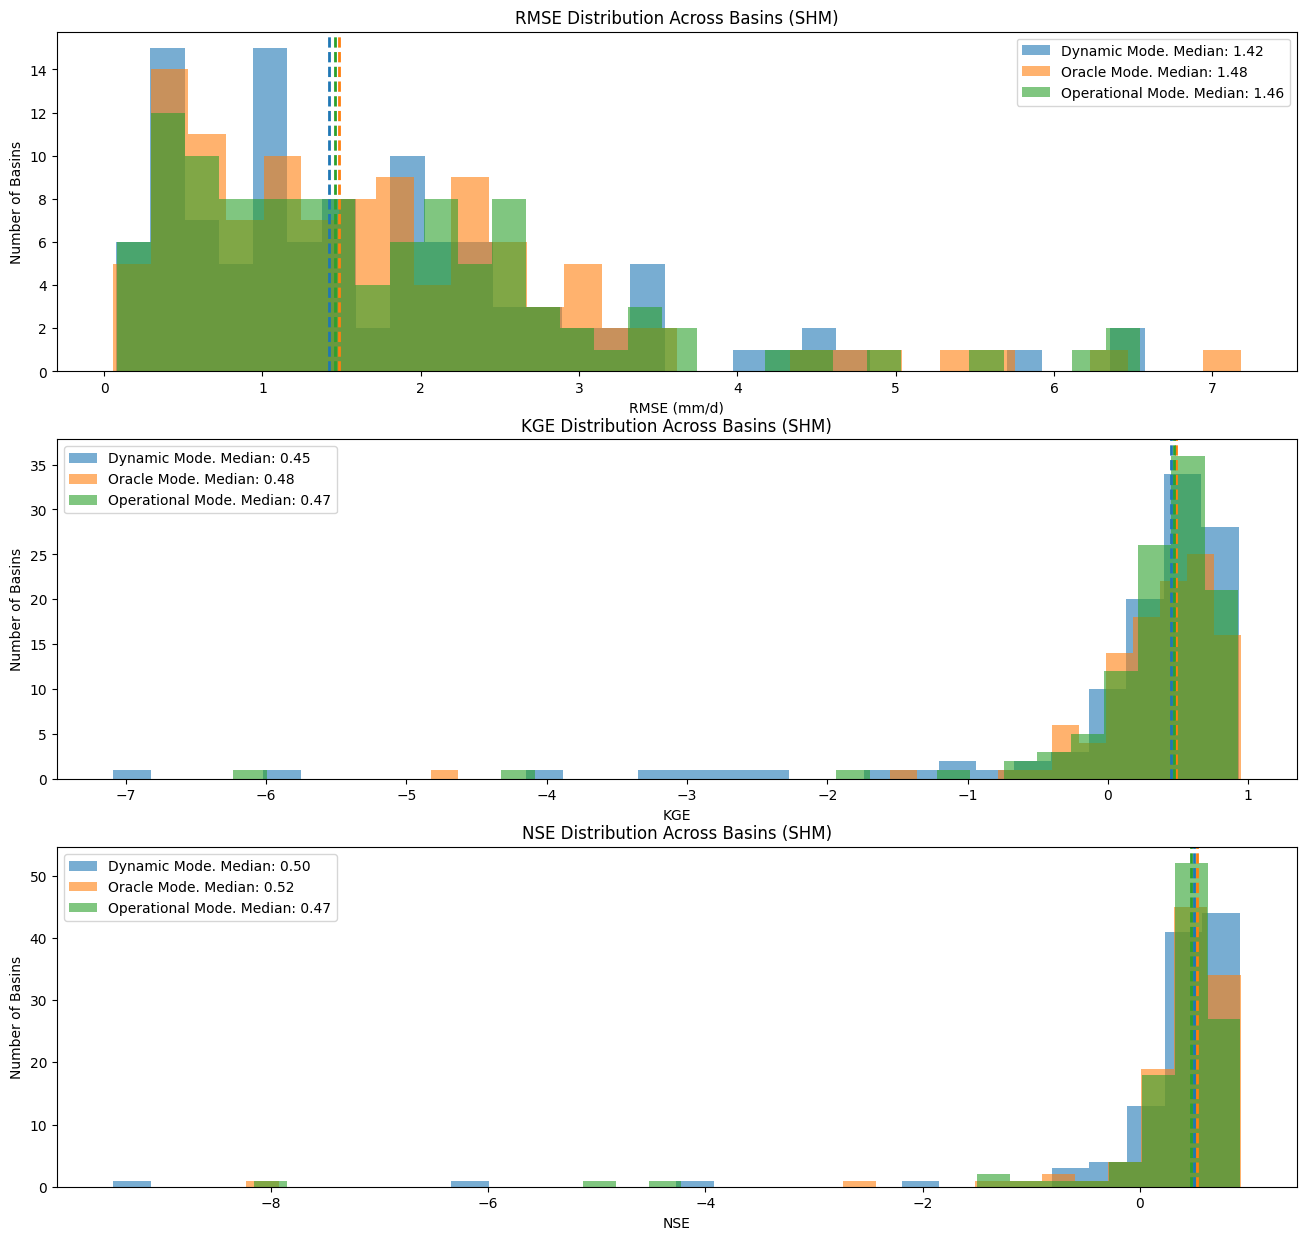

In [4]:
num_bins = 30
a = 0.6

fig, ax = plt.subplots(3, 1, figsize=(16,15))
ax[0].hist(shm_metrics['dynamic_rmse'], bins=num_bins, alpha=a, label='Dynamic Mode. Median: {:.2f}'.format(shm_metrics['dynamic_rmse'].median()))
ax[0].axvline(shm_metrics['dynamic_rmse'].median(), color='tab:blue', linestyle='dashed', linewidth=2)
ax[0].hist(shm_metrics['oracle_rmse'], bins=num_bins, alpha=a, label='Oracle Mode. Median: {:.2f}'.format(shm_metrics['oracle_rmse'].median()))
ax[0].axvline(shm_metrics['oracle_rmse'].median(), color='tab:orange', linestyle='dashed', linewidth=2)
ax[0].hist(shm_metrics['operational_rmse'], bins=num_bins, alpha=a, label='Operational Mode. Median: {:.2f}'.format(shm_metrics['operational_rmse'].median()))
ax[0].axvline(shm_metrics['operational_rmse'].median(), color='tab:green', linestyle='dashed', linewidth=2)
ax[0].set_title("RMSE Distribution Across Basins (SHM)")
ax[0].set_xlabel("RMSE (mm/d)")
ax[0].set_ylabel("Number of Basins")
ax[0].legend() 

ax[1].hist(shm_metrics['dynamic_kge'], bins=num_bins, alpha=a, label='Dynamic Mode. Median: {:.2f}'.format(shm_metrics['dynamic_kge'].median()))
ax[1].axvline(shm_metrics['dynamic_kge'].median(), color='tab:blue', linestyle='dashed', linewidth=2)
ax[1].hist(shm_metrics['oracle_kge'], bins=num_bins, alpha=a, label='Oracle Mode. Median: {:.2f}'.format(shm_metrics['oracle_kge'].median()))
ax[1].axvline(shm_metrics['oracle_kge'].median(), color='tab:orange', linestyle='dashed', linewidth=2)
ax[1].hist(shm_metrics['operational_kge'], bins=num_bins, alpha=a, label='Operational Mode. Median: {:.2f}'.format(shm_metrics['operational_kge'].median()))
ax[1].axvline(shm_metrics['operational_kge'].median(), color='tab:green', linestyle='dashed', linewidth=2)
ax[1].set_title("KGE Distribution Across Basins (SHM)")
ax[1].set_xlabel("KGE")
ax[1].set_ylabel("Number of Basins")
ax[1].legend() 

ax[2].hist(shm_metrics['dynamic_nse'], bins=30, alpha=a, label='Dynamic Mode. Median: {:.2f}'.format(shm_metrics['dynamic_nse'].median()))
ax[2].axvline(shm_metrics['dynamic_nse'].median(), color='tab:blue', linestyle='dashed', linewidth=2)
ax[2].hist(shm_metrics['oracle_nse'], bins=30, alpha=a, label='Oracle Mode. Median: {:.2f}'.format(shm_metrics['oracle_nse'].median()))
ax[2].axvline(shm_metrics['oracle_nse'].median(), color='tab:orange', linestyle='dashed', linewidth=2)
ax[2].hist(shm_metrics['operational_nse'], bins=30, alpha=a, label='Operational Mode. Median: {:.2f}'.format(shm_metrics['operational_nse'].median()))
ax[2].axvline(shm_metrics['operational_nse'].median(), color='tab:green', linestyle='dashed', linewidth=2)
ax[2].set_title("NSE Distribution Across Basins (SHM)")
ax[2].set_xlabel("NSE")
ax[2].set_ylabel("Number of Basins")
ax[2].legend()

## Training Modes Comparison for NSE

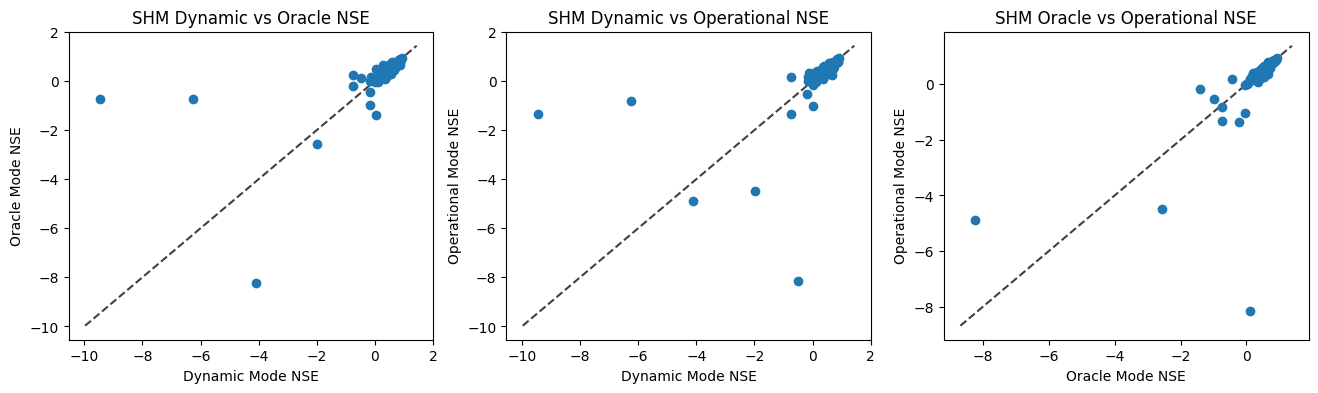

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(16,4))
ax[0].plot(shm_metrics['dynamic_nse'], shm_metrics['oracle_nse'], 'o')
ax[0].set_title("SHM Dynamic vs Oracle NSE")
ax[0].set_xlabel("Dynamic Mode NSE")
ax[0].set_ylabel("Oracle Mode NSE")
lims0 = [np.min([ax[0].get_xlim(), ax[0].get_ylim()]), np.max([ax[0].get_xlim(), ax[0].get_ylim()])]
ax[0].plot(lims0, lims0, 'k--', alpha=0.75, zorder=0)

ax[1].plot(shm_metrics['dynamic_nse'], shm_metrics['operational_nse'], 'o')
ax[1].set_title("SHM Dynamic vs Operational NSE")
ax[1].set_xlabel("Dynamic Mode NSE")
ax[1].set_ylabel("Operational Mode NSE")
lims1 = [np.min([ax[1].get_xlim(), ax[1].get_ylim()]), np.max([ax[1].get_xlim(), ax[1].get_ylim()])]
ax[1].plot(lims1, lims1, 'k--', alpha=0.75, zorder=0)

ax[2].plot(shm_metrics['oracle_nse'], shm_metrics['operational_nse'], 'o')
ax[2].set_title("SHM Oracle vs Operational NSE")
ax[2].set_xlabel("Oracle Mode NSE")
ax[2].set_ylabel("Operational Mode NSE")
lims2 = [np.min([ax[2].get_xlim(), ax[2].get_ylim()]), np.max([ax[2].get_xlim(), ax[2].get_ylim()])]
ax[2].plot(lims2, lims2, 'k--', alpha=0.75, zorder=0)

# LSTM Benchmark (Need Fixing)

In [7]:
import pickle
from pathlib import Path
import pandas as pd
import numpy as np
import torch.nn as nn

from neuralhydrology.utils.config import Config

import matplotlib.pyplot as plt
import torch
from neuralhydrology.evaluation import metrics
from neuralhydrology.nh_run import start_run, eval_run

from neuralhydrology.evaluation.metrics import nse, kge, rmse
import xarray as xr

In [3]:
lstm_path = Path("runs/EXP1_LSTM_CAMELS_Benchmark_0602_153355")
with open(lstm_path / "test" / "model_epoch030" / "test_results.p", "rb") as fp:
    lstm_results = pickle.load(fp)

## Verify metircs calculated correctly

In [ ]:
basin = '08202700' #'02231000' #'08202700'
nse(xr.DataArray(lstm_results[basin]['1D']['xr']['QObs(mm/d)_obs'].squeeze(drop=True)), 
    xr.DataArray(lstm_results[basin]['1D']['xr']['QObs(mm/d)_sim'].squeeze(drop=True)))

0.5881643891334534

In [19]:
lstm_results[basin]['1D']['NSE']

0.5895776152610779

It is pretty confusing why they don't match up exactly. Should bring this up to team.

## Metrics Comparison: NSE, RMSE, KGE

In [39]:
lstm_metric = {'basin': [], 'nse': [], 'rmse': [], 'kge': []}
basin_keys = list(lstm_results.keys())

# Dynamic Mode
for basin in basin_keys:
    lstm_nse = nse(xr.DataArray(lstm_results[basin]['1D']['xr']['QObs(mm/d)_obs'].squeeze(drop=True)),
                     xr.DataArray(lstm_results[basin]['1D']['xr']['QObs(mm/d)_sim'].squeeze(drop=True)))
    lstm_rmse = rmse(xr.DataArray(lstm_results[basin]['1D']['xr']['QObs(mm/d)_obs'].squeeze(drop=True)),
                        xr.DataArray(lstm_results[basin]['1D']['xr']['QObs(mm/d)_sim'].squeeze(drop=True)))
    lstm_kge = kge(xr.DataArray(lstm_results[basin]['1D']['xr']['QObs(mm/d)_obs'].squeeze(drop=True)),
                        xr.DataArray(lstm_results[basin]['1D']['xr']['QObs(mm/d)_sim'].squeeze(drop=True)))
    
    # Append to results dictionary
    lstm_metric['basin'].append(basin)
    lstm_metric['nse'].append(float(lstm_nse))
    lstm_metric['rmse'].append(float(lstm_rmse))
    lstm_metric['kge'].append(float(lstm_kge))
    
lstm_metric = pd.DataFrame(lstm_metric).set_index('basin')

In [40]:
print(f"LSTM's Median RMSE: {lstm_metric['rmse'].median():.3f}, KGE : {np.median(lstm_metric['kge']):.3f},NSE : {np.median(lstm_metric['nse']):.3f}")


LSTM's Median RMSE: 1.342, KGE : 0.476,NSE : 0.550


## Comparison to Dynamic of dCFE and SHM

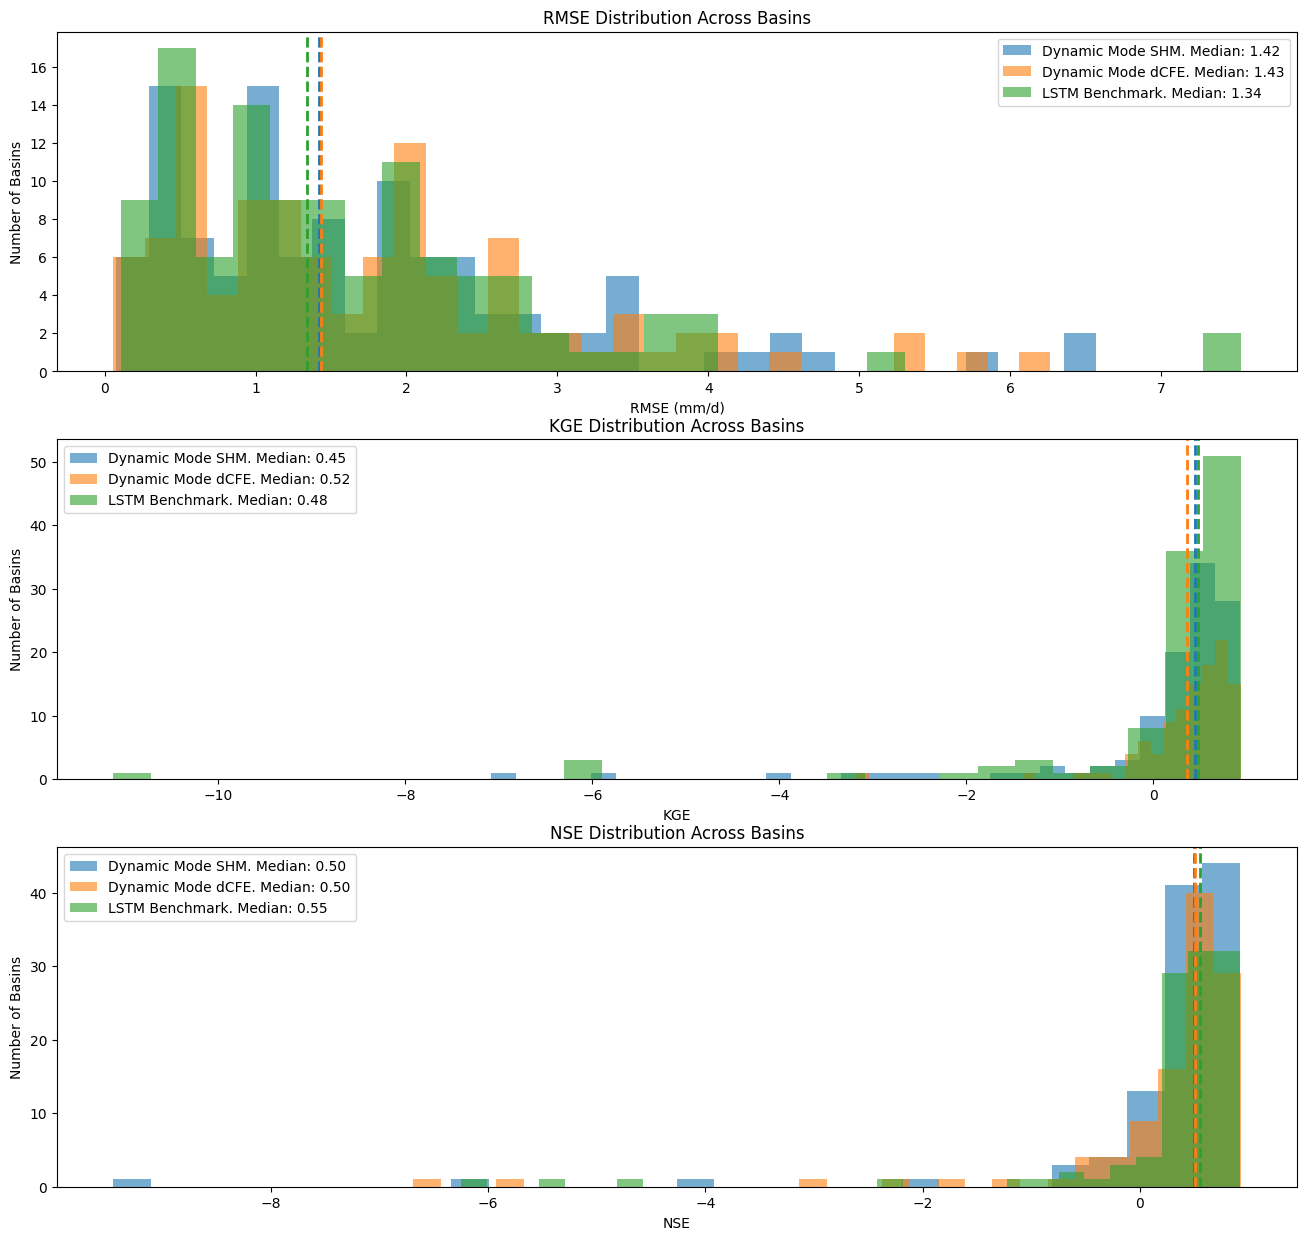

In [47]:
num_bins = 30
a = 0.6

fig, ax = plt.subplots(3, 1, figsize=(16,15))
ax[0].hist(shm_metrics['dynamic_rmse'], bins=num_bins, alpha=a, label='Dynamic Mode SHM. Median: {:.2f}'.format(shm_metrics['dynamic_rmse'].median()))
ax[0].axvline(shm_metrics['dynamic_rmse'].median(), color='tab:blue', linestyle='dashed', linewidth=2)
ax[0].hist(rmse_results['dynamic_rmse'], bins=num_bins, alpha=a, label='Dynamic Mode dCFE. Median: {:.2f}'.format(np.median(rmse_results['dynamic_rmse'])))
ax[0].axvline(np.median(rmse_results['dynamic_rmse']), color='tab:orange', linestyle='dashed', linewidth=2)
ax[0].hist(lstm_metric['rmse'], bins=num_bins, alpha=a, label='LSTM Benchmark. Median: {:.2f}'.format(lstm_metric['rmse'].median()))
ax[0].axvline(lstm_metric['rmse'].median(), color='tab:green', linestyle='dashed', linewidth=2)
ax[0].set_title("RMSE Distribution Across Basins")
ax[0].set_xlabel("RMSE (mm/d)")
ax[0].set_ylabel("Number of Basins")
ax[0].legend() 

ax[1].hist(shm_metrics['dynamic_kge'], bins=num_bins, alpha=a, label='Dynamic Mode SHM. Median: {:.2f}'.format(shm_metrics['dynamic_kge'].median()))
ax[1].axvline(shm_metrics['dynamic_kge'].median(), color='tab:blue', linestyle='dashed', linewidth=2)
ax[1].hist(kge_results['dynamic_kge'], bins=num_bins, alpha=a, label='Dynamic Mode dCFE. Median: {:.2f}'.format(np.median(kge_results['dynamic_kge'])))
ax[1].axvline(np.median(kge_results['oracle_kge']), color='tab:orange', linestyle='dashed', linewidth=2)
ax[1].hist(lstm_metric['kge'], bins=num_bins, alpha=a, label='LSTM Benchmark. Median: {:.2f}'.format(lstm_metric['kge'].median()))
ax[1].axvline(lstm_metric['kge'].median(), color='tab:green', linestyle='dashed', linewidth=2)
ax[1].set_title("KGE Distribution Across Basins")
ax[1].set_xlabel("KGE")
ax[1].set_ylabel("Number of Basins")
ax[1].legend() 

ax[2].hist(shm_metrics['dynamic_nse'], bins=30, alpha=a, label='Dynamic Mode SHM. Median: {:.2f}'.format(shm_metrics['dynamic_nse'].median()))
ax[2].axvline(shm_metrics['dynamic_nse'].median(), color='tab:blue', linestyle='dashed', linewidth=2)
ax[2].hist(nse_results['dynamic_nse'], bins=30, alpha=a, label='Dynamic Mode dCFE. Median: {:.2f}'.format(np.median(nse_results['dynamic_nse'])))
ax[2].axvline(np.median(nse_results['dynamic_nse']), color='tab:orange', linestyle='dashed', linewidth=2)
ax[2].hist(lstm_metric['nse'], bins=30, alpha=a, label='LSTM Benchmark. Median: {:.2f}'.format(lstm_metric['nse'].median()))
ax[2].axvline(lstm_metric['nse'].median(), color='tab:green', linestyle='dashed', linewidth=2)
ax[2].set_title("NSE Distribution Across Basins")
ax[2].set_xlabel("NSE")
ax[2].set_ylabel("Number of Basins")
ax[2].legend()

# 531 Basin Param & States

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import torch.nn as nn

from neuralhydrology.utils.config import Config

import matplotlib.pyplot as plt
import torch
import xarray as xr
from neuralhydrology.nh_run import start_run, eval_run
import pickle

In [3]:
lstm_benchmark_run_dir = Path("runs/EXP1_LSTM_Full_CAMELS_Benchmark_2302_100517")
with open(lstm_benchmark_run_dir / "test" / "model_epoch030" / "test_results.p", "rb") as fp:
    lstm_benchmark_results = pickle.load(fp)
full_dynamic_shm_run_dir = Path("runs/EXP1_SHM_CAMELS_531basin_Dynamic_1202_133700")
with open(full_dynamic_shm_run_dir / "test" / "model_epoch030" / "test_results.p", "rb") as fp:
    full_dynamic_shm_results = pickle.load(fp)
full_oracle_shm_run_dir = Path("runs/EXP1_SHM_CAMELS_531basin_OracleAvg_1702_232011")
with open(full_oracle_shm_run_dir / "test" / "model_epoch030" / "test_results.p", "rb") as fp:
    full_oracle_shm_results = pickle.load(fp)
full_operational_shm_run_dir = Path("runs/EXP1_SHM_CAMELS_531basin_OperationalAvg_1702_160814")
with open(full_operational_shm_run_dir / "test" / "model_epoch030" / "test_results.p", "rb") as fp:
    full_operational_shm_results = pickle.load(fp)
    
# grab keys of list of basins
basin_keys = list(lstm_benchmark_results.keys())

with open(full_dynamic_shm_run_dir / "test" / "model_epoch030" / "test_all_output.p", "rb") as fp:
    full_dynamic_shm_all_results = pickle.load(fp)
with open(full_oracle_shm_run_dir / "test" / "model_epoch030" / "test_all_output.p", "rb") as fp:
    full_oracle_shm_all_results = pickle.load(fp)
with open(full_operational_shm_run_dir / "test" / "model_epoch030" / "test_all_output.p", "rb") as fp:
    full_operational_shm_all_results = pickle.load(fp)
    
# grab keys of parmeters and internal states
param_keys = list(full_dynamic_shm_all_results[basin_keys[0]]["spinup_parameters"].keys())
state_keys = list(full_dynamic_shm_all_results[basin_keys[0]]["spinup_internal_states"].keys())

## SHM Parameters


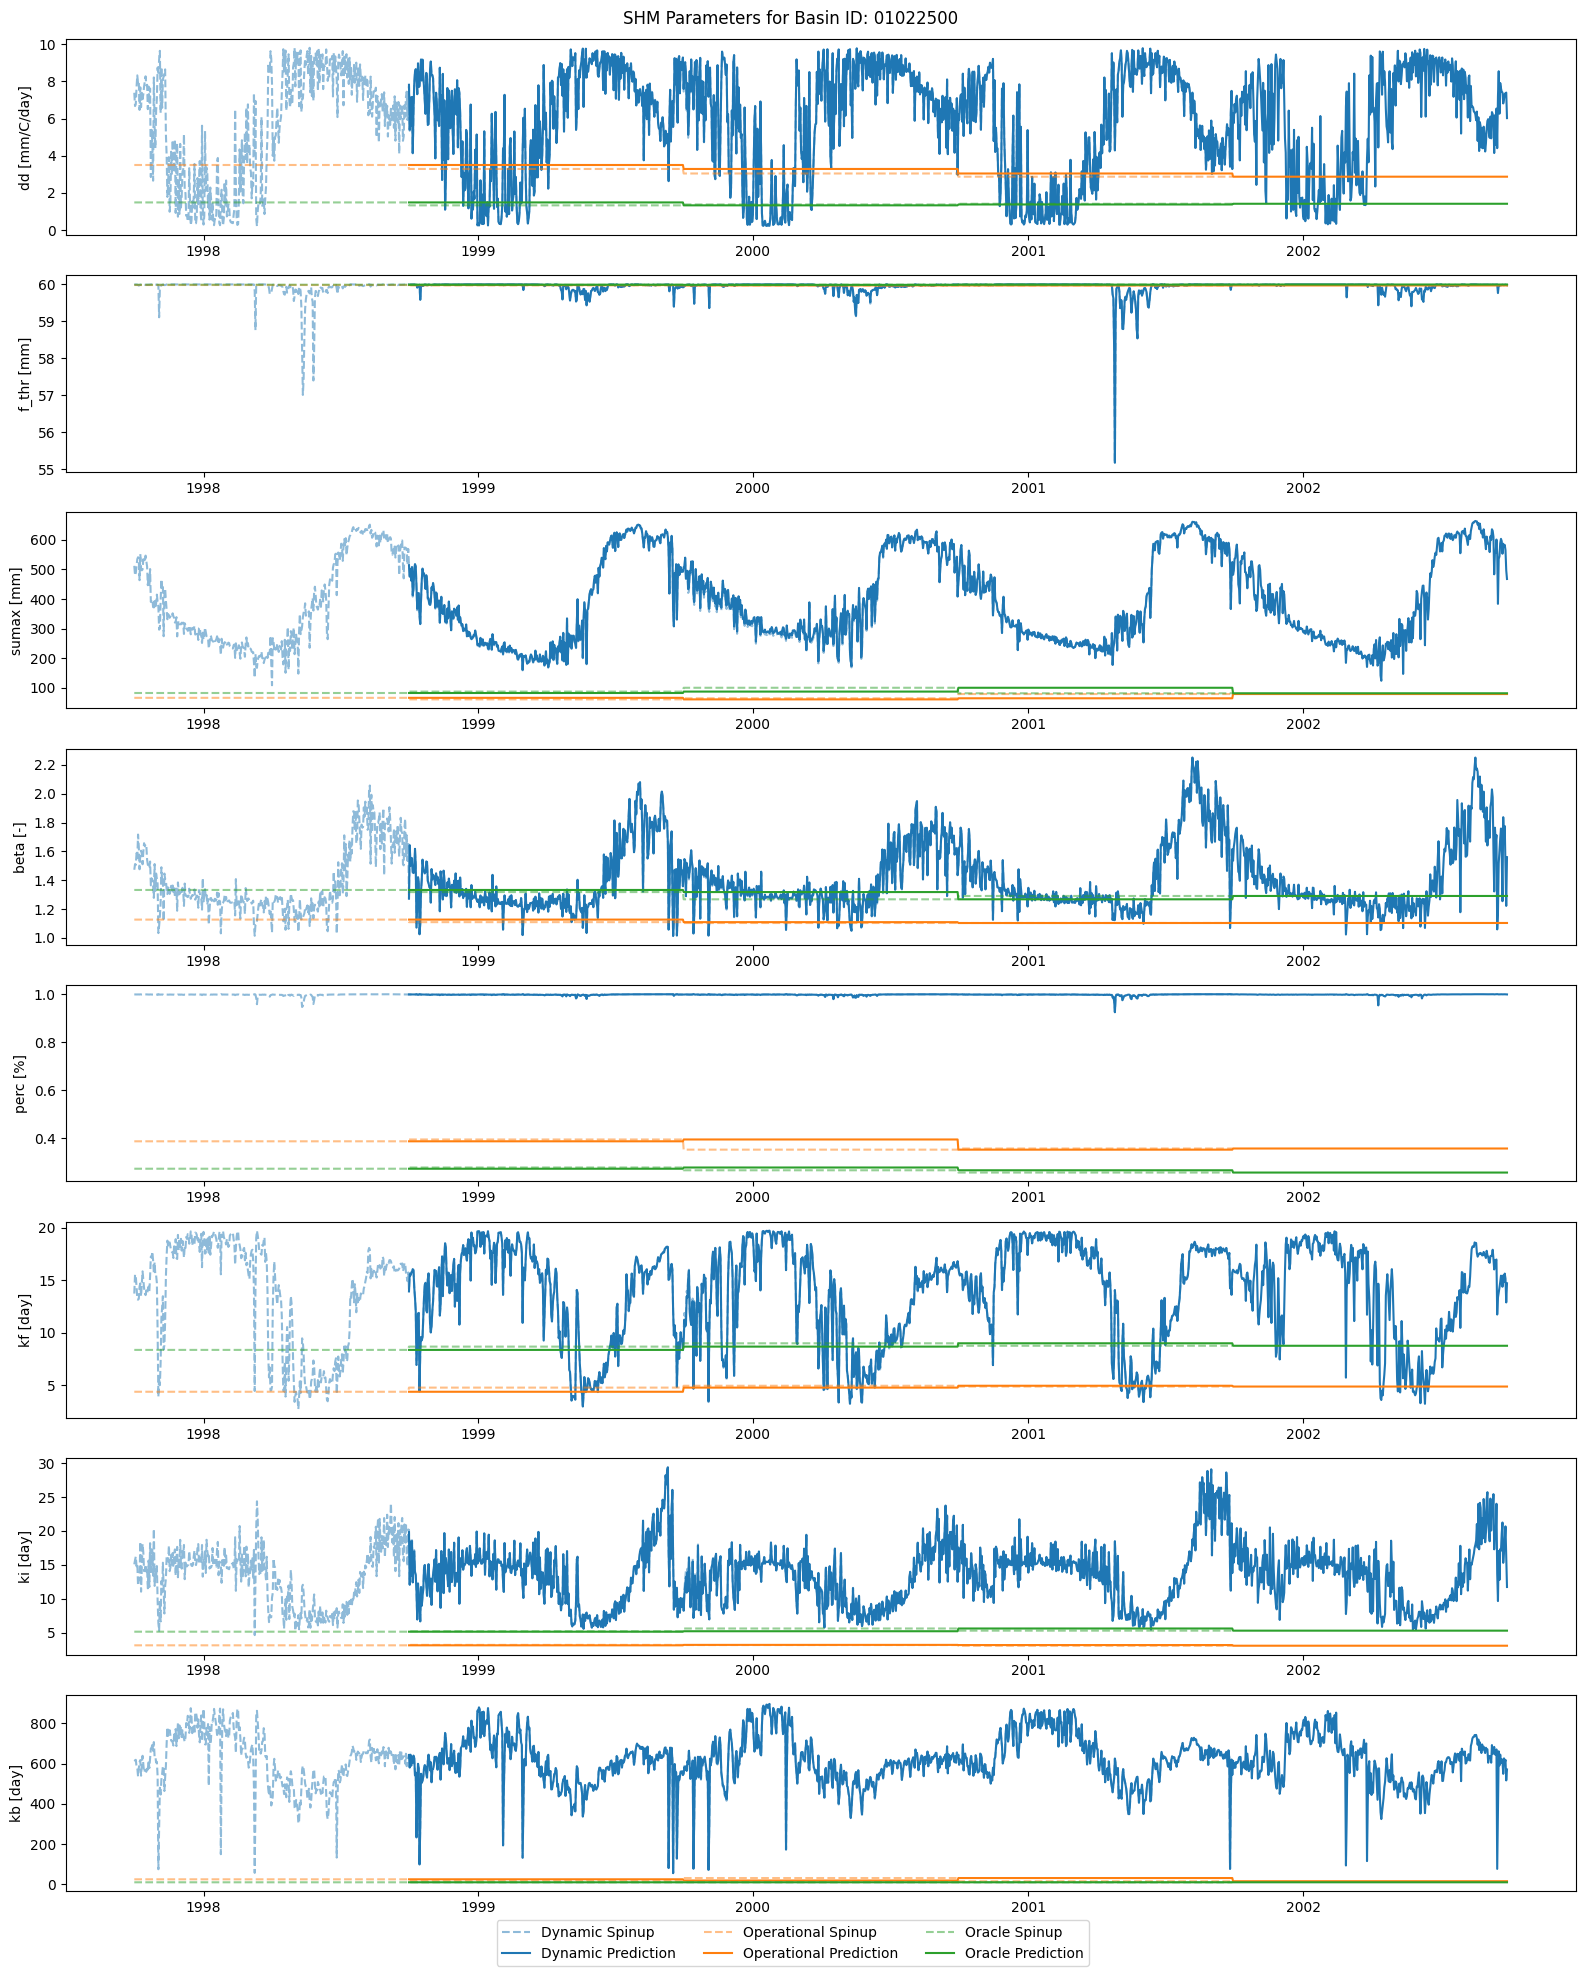

In [4]:
param_unit_keys = ['[mm/C/day]', '[mm]', '[mm]', '[-]', '[%]', '[day]', '[day]', '[day]']
basin = '01022500' #'02177000' #basin_keys[3]
param_dates = full_dynamic_shm_all_results['datetime']

fig, ax = plt.subplots(figsize=(16,2.5*len(param_keys)), nrows=len(param_keys), ncols=1)
for i, param_interest in enumerate(param_keys):
    label_dynamic_spinup = "Dynamic Spinup" if i == 0 else None
    label_dynamic_prediction = "Dynamic Prediction" if i == 0 else None
    label_operational_spinup = "Operational Spinup" if i == 0 else None
    label_operational_prediction = "Operational Prediction" if i == 0 else None
    label_oracle_spinup = "Oracle Spinup" if i == 0 else None
    label_oracle_prediction = "Oracle Prediction" if i == 0 else None
    ax[i].plot(param_dates, full_dynamic_shm_all_results[basin]["spinup_parameters"][param_interest], 
               color="tab:blue", label=label_dynamic_spinup, linestyle='--', alpha = 0.5)
    ax[i].plot(param_dates, full_dynamic_shm_all_results[basin]["prediction_parameters"][param_interest], 
               color="tab:blue", label=label_dynamic_prediction, linestyle='-')
    ax[i].plot(param_dates, full_operational_shm_all_results[basin]["spinup_parameters"][param_interest],
               color="tab:orange", label=label_operational_spinup, linestyle='--', alpha = 0.5)
    ax[i].plot(param_dates, full_operational_shm_all_results[basin]["prediction_parameters"][param_interest],
               color="tab:orange", label=label_operational_prediction, linestyle='-')
    ax[i].plot(param_dates, full_oracle_shm_all_results[basin]["spinup_parameters"][param_interest],
               color="tab:green", label=label_oracle_spinup, linestyle='--', alpha = 0.5)
    ax[i].plot(param_dates, full_oracle_shm_all_results[basin]["prediction_parameters"][param_interest],
               color="tab:green", label=label_oracle_prediction, linestyle='-')
    ax[i].set_ylabel(f"{param_interest} {param_unit_keys[i]}")
fig.legend(loc="lower center", ncol=3)
fig.suptitle(f"SHM Parameters for Basin ID: {basin}")
plt.tight_layout(rect=[0, 0.02, 1, 0.99])

## SHM Internal States

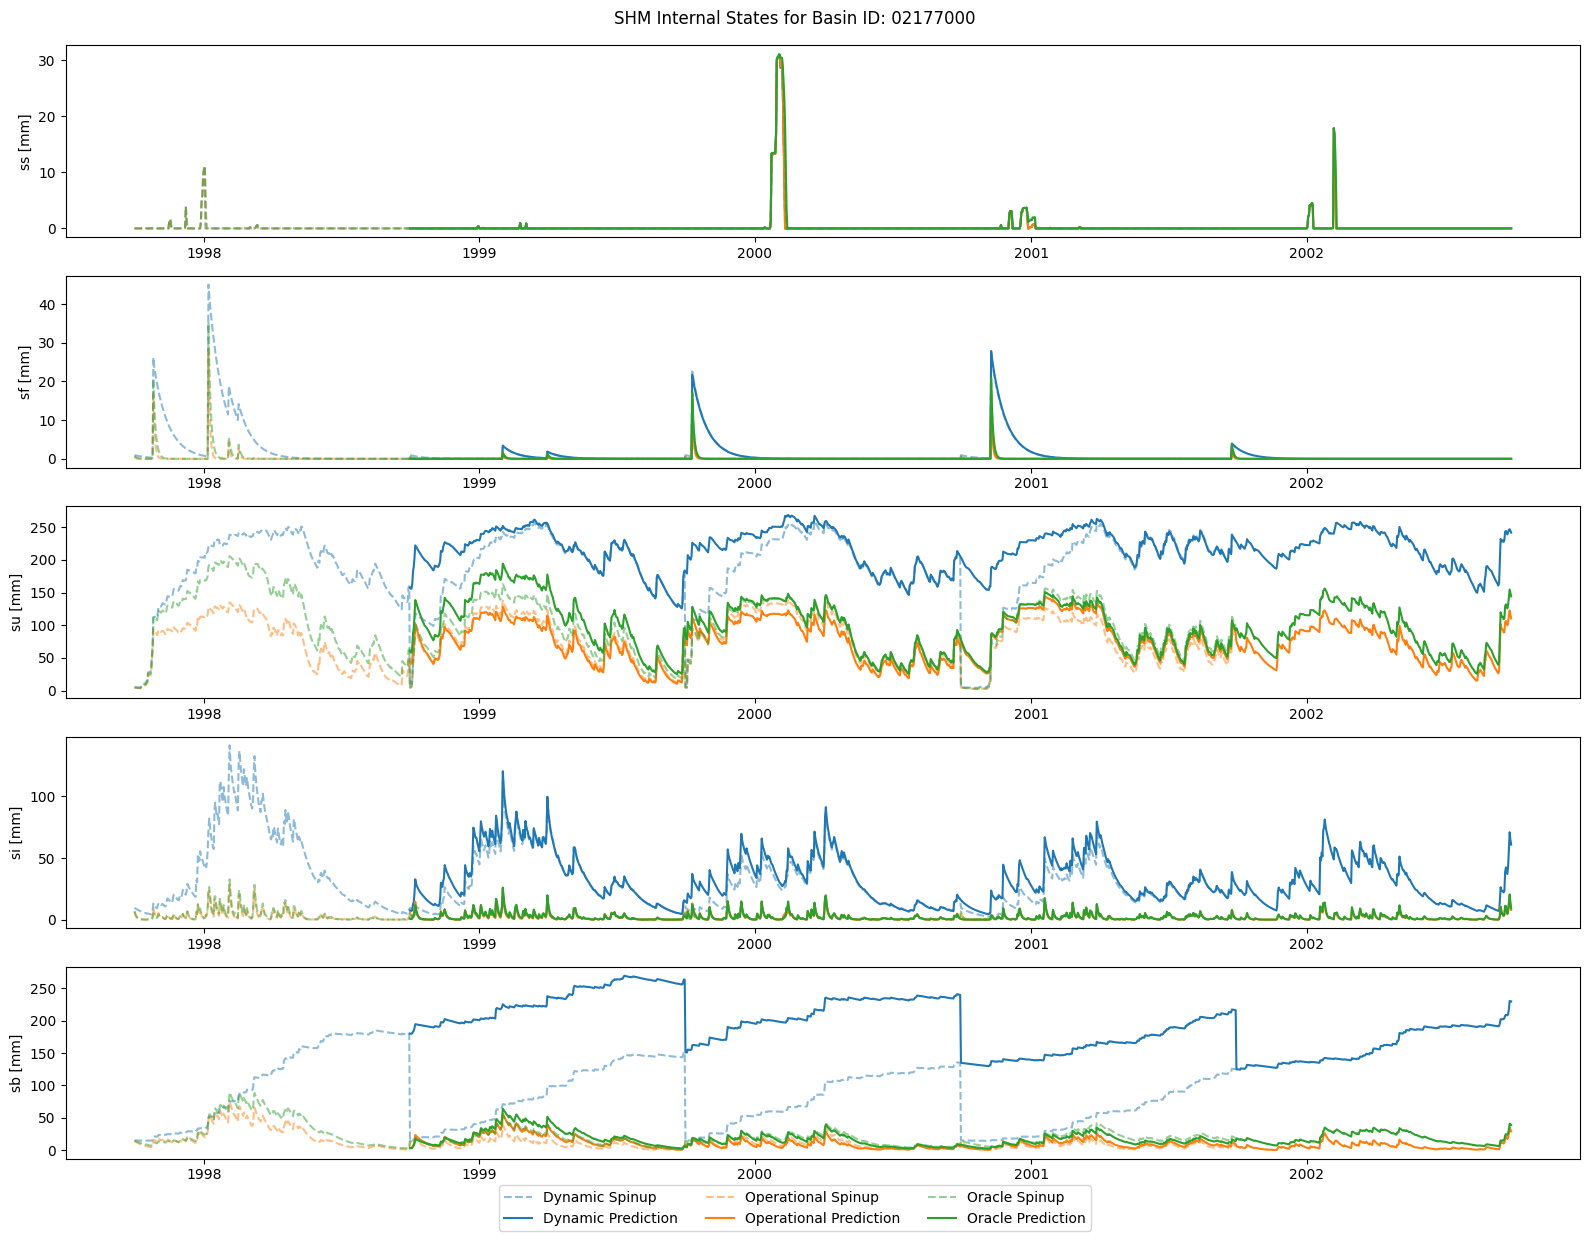

In [13]:
basin = '02177000' #basin_keys[3]
state_dates =full_dynamic_shm_all_results['datetime']
fig, ax = plt.subplots(figsize=(16,2.5*len(state_keys)), nrows=len(state_keys), ncols=1)
for i, state_interest in enumerate(state_keys):
    label_dynamic_spinup = "Dynamic Spinup" if i == 0 else None
    label_dynamic_prediction = "Dynamic Prediction" if i == 0 else None
    label_operational_spinup = "Operational Spinup" if i == 0 else None
    label_operational_prediction = "Operational Prediction" if i == 0 else None
    label_oracle_spinup = "Oracle Spinup" if i == 0 else None
    label_oracle_prediction = "Oracle Prediction" if i == 0 else None
    ax[i].plot(param_dates, full_dynamic_shm_all_results[basin]["spinup_internal_states"][state_interest], 
               color="tab:blue", label=label_dynamic_spinup, linestyle='--', alpha = 0.5)
    ax[i].plot(param_dates, full_dynamic_shm_all_results[basin]["prediction_internal_states"][state_interest], 
               color="tab:blue", label=label_dynamic_prediction, linestyle='-')
    ax[i].plot(param_dates, full_operational_shm_all_results[basin]["spinup_internal_states"][state_interest],
               color="tab:orange", label=label_operational_spinup, linestyle='--', alpha = 0.5)
    ax[i].plot(param_dates, full_operational_shm_all_results[basin]["prediction_internal_states"][state_interest],
               color="tab:orange", label=label_operational_prediction, linestyle='-')
    ax[i].plot(param_dates, full_oracle_shm_all_results[basin]["spinup_internal_states"][state_interest],
               color="tab:green", label=label_oracle_spinup, linestyle='--', alpha = 0.5)
    ax[i].plot(param_dates, full_oracle_shm_all_results[basin]["prediction_internal_states"][state_interest],
               color="tab:green", label=label_oracle_prediction, linestyle='-')
    ax[i].set_ylabel(f"{state_interest} [mm]")
fig.legend(loc="lower center", ncol=3)
fig.suptitle(f"SHM Internal States for Basin ID: {basin}")
plt.tight_layout(rect=[0, 0.03, 1, 0.99])
